<a href="https://colab.research.google.com/github/SohaMoamen/AI_Agent_smart_city/blob/main/Ai_agent_smart_city.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
======================================================================
DataManager.py

Smart City Multi-Agent Reinforcement Learning Framework

Author:
    Soha Abdelmoamen

Description
-----------
This module manages all CityPulse datasets.

Responsibilities
----------------
1. Load datasets
2. Validate datasets
3. Clean datasets
4. Generate City Snapshots
5. Normalize features
6. Build temporal index
7. Build spatial index
8. Build caches
9. Provide states for AI Agents

Datasets
--------
Traffic
Pollution
Weather
Culture Events
Library Events

Study Period
------------
01-Aug-2014
to
30-Sep-2014

======================================================================
"""

from __future__ import annotations

import os
import logging
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import pandas as pd

from sklearn.neighbors import KDTree
from sklearn.preprocessing import MinMaxScaler


# ============================================================
# Logger
# ============================================================

logging.basicConfig(

    level=logging.INFO,

    format="%(asctime)s | %(levelname)s | %(message)s"

)

logger = logging.getLogger(__name__)


# ============================================================
# Default Configuration
# ============================================================

DEFAULT_CONFIG = {

    # Study period
    "start_date": "2014-08-01 00:00:00",

    "end_date": "2014-09-30 23:40:00",

    # Time Resolution
    "time_step_minutes": 20,

    # Weather
    "weather_fill_method": "ffill",

    # Snapshot
    "traffic_vehicle_aggregation": "sum",

    "traffic_speed_aggregation": "mean",

    "pollution_aggregation": "mean",

    # Output
    "snapshot_filename": "CitySnapshot.parquet",

    # Random Seed
    "seed": 42

}


# ============================================================
# CityPulse Data Manager
# ============================================================

class CityPulseDataManager:
    """
    Main class responsible for handling all CityPulse datasets.

    Workflow
    --------

    load_data()

            ↓

    validate_schema()

            ↓

    clean_data()

            ↓

    feature_engineering()

            ↓

    build_city_snapshot()

            ↓

    normalize()

            ↓

    build_indices()

            ↓

    build_cache()

            ↓

    get_snapshot()

    """

    ###########################################################
    # Constructor
    ###########################################################

    def __init__(

        self,

        base_path: str,

        config: Optional[Dict] = None

    ):

        # ------------------------------------------------------
        # Configuration
        # ------------------------------------------------------

        self.config = DEFAULT_CONFIG.copy()

        if config is not None:

            self.config.update(config)

        # ------------------------------------------------------
        # Paths
        # ------------------------------------------------------

        self.base_path = Path(base_path)

        if not self.base_path.exists():

            raise FileNotFoundError(

                f"Dataset folder does not exist:\n{self.base_path}"

            )

        # ------------------------------------------------------
        # Random Seed
        # ------------------------------------------------------

        np.random.seed(

            self.config["seed"]

        )

        # ------------------------------------------------------
        # Datasets
        # ------------------------------------------------------

        self.traffic = None

        self.pollution = None

        self.weather = None

        self.culture = None

        self.library = None

        # ------------------------------------------------------
        # Generated Dataset
        # ------------------------------------------------------

        self.city_snapshot = None

        # ------------------------------------------------------
        # Feature Scaler
        # ------------------------------------------------------

        self.scaler = MinMaxScaler()

        # ------------------------------------------------------
        # Spatial Indices
        # ------------------------------------------------------

        self.traffic_tree = None

        self.snapshot_tree = None

        # ------------------------------------------------------
        # Temporal Index
        # ------------------------------------------------------

        self.time_index = {}

        # ------------------------------------------------------
        # Runtime Cache
        # ------------------------------------------------------

        self.cache = {}

        logger.info("CityPulseDataManager initialized successfully.")
        # ------------------------------------------------------
        # Snapshot Dataset
        # ------------------------------------------------------

        self.city_snapshot = None

        # ------------------------------------------------------
        # Normalized Snapshot
        # ------------------------------------------------------

        self.normalized_snapshot = None

        # ------------------------------------------------------
        # Feature Names
        # ------------------------------------------------------

        self.feature_names = []

        # ------------------------------------------------------
        # Temporal Cache
        # ------------------------------------------------------

        self.snapshot_cache = {}
    ###########################################################
    # Properties
    ###########################################################

    @property
    def start_date(self):

        return pd.Timestamp(

            self.config["start_date"]

        )

    @property
    def end_date(self):

        return pd.Timestamp(

            self.config["end_date"]

        )

    @property
    def time_step(self):

        return self.config["time_step_minutes"]
    ###########################################################
    # Load Datasets
    ###########################################################

    def load_data(self) -> None:
        """
        Load all standardized CityPulse datasets.
        """

        logger.info("=" * 60)
        logger.info("Loading CityPulse datasets...")
        logger.info("=" * 60)

        files = {

            "traffic": "Traffic_Standardized.csv",

            "pollution": "Pollution_Standardized.csv",

            "weather": "Weather_Standardized.csv",

            "culture": "Culture Events_Standardized.csv",

            "library": "Library_Standardized.csv"

        }

        try:

            self.traffic = pd.read_csv(
                self.base_path / files["traffic"],
                parse_dates=["timestamp"]
            )

            self.pollution = pd.read_csv(
                self.base_path / files["pollution"],
                parse_dates=["timestamp"]
            )

            self.weather = pd.read_csv(
                self.base_path / files["weather"],
                parse_dates=["timestamp"]
            )

            self.culture = pd.read_csv(
                self.base_path / files["culture"],
                parse_dates=["timestamp"]
            )

            self.library = pd.read_csv(
                self.base_path / files["library"],
                parse_dates=["timestamp"]
            )

        except Exception as e:

            logger.error(f"Dataset loading failed: {e}")

            raise

        logger.info("Datasets loaded successfully.\n")

        #self.summary()


    ###########################################################
    # Validate Dataset Schema
    ###########################################################

    def validate_schema(self) -> None:
        """
        Validate required columns.
        """

        logger.info("=" * 60)
        logger.info("Validating datasets...")
        logger.info("=" * 60)

        required = {

            "traffic":[

                "timestamp",

                "latitude",

                "longitude",

                "vehicleCount",

                "avgSpeed"

            ],

            "pollution":[

                "timestamp",

                "latitude",

                "longitude",

                "ozone",

                "particullate_matter",

                "carbon_monoxide",

                "sulfure_dioxide",

                "nitrogen_dioxide"

            ],

            "weather":[

                "timestamp",

                "tempm",

                "hum",

                "pressurem",

                "wspdm",

                "wdird"

            ],

            "culture":[

                "timestamp"

            ],

            "library":[

                "timestamp"

            ]

        }

        datasets = {

            "traffic": self.traffic,

            "pollution": self.pollution,

            "weather": self.weather,

            "culture": self.culture,

            "library": self.library

        }

        for name, cols in required.items():

            df = datasets[name]

            missing = [

                c

                for c in cols

                if c not in df.columns

            ]

            if len(missing) > 0:

                raise ValueError(

                    f"{name} dataset is missing columns: {missing}"

                )

            logger.info(f"{name:<12} ✓")

        logger.info("=" * 60)
        logger.info("Schema validation completed successfully.")
        logger.info("=" * 60)
    # ==========================================================
    # Clean Data Pipeline
    # ==========================================================

    def clean_data(self) -> None:
        """
        Complete preprocessing pipeline.

        Steps
        -----
        1. Sort datasets
        2. Remove duplicated records
        3. Handle missing values
        4. Filter study period
        5. Generate temporal features
        """

        logger.info("=" * 60)
        logger.info("Cleaning datasets...")
        logger.info("=" * 60)

        self._sort_data()

        self._remove_duplicates()

        self._handle_missing_values()

        self._filter_study_period()

        self._feature_engineering()

        logger.info("Cleaning completed successfully.")
        logger.info("=" * 60)


    # ==========================================================
    # Sort Datasets
    # ==========================================================

    def _sort_data(self):

        datasets = [

            self.traffic,

            self.pollution,

            self.weather,

            self.culture,

            self.library

        ]

        for df in datasets:

            df.sort_values(

                "timestamp",

                inplace=True

            )

            df.reset_index(

                drop=True,

                inplace=True

            )


    # ==========================================================
    # Remove Duplicate Records
    # ==========================================================

    def _remove_duplicates(self):

        self.traffic.drop_duplicates(inplace=True)

        self.pollution.drop_duplicates(inplace=True)

        self.weather.drop_duplicates(inplace=True)

        self.culture.drop_duplicates(inplace=True)

        self.library.drop_duplicates(inplace=True)


    # ==========================================================
    # Missing Values
    # ==========================================================

    def _handle_missing_values(self):

        logger.info("Handling missing values...")

        ####################################################
        # Weather
        ####################################################

        self.weather = self.weather.ffill()

        self.weather = self.weather.bfill()

        ####################################################
        # Culture
        ####################################################

        self.culture.fillna(

            {

                "price": 0

            },

            inplace=True

        )

        ####################################################
        # Library
        ####################################################

        if "content" in self.library.columns:

            self.library["content"] = self.library["content"].fillna("")

        if "imageurl" in self.library.columns:

            self.library["imageurl"] = self.library["imageurl"].fillna("")


    # ==========================================================
    # Filter Study Period
    # ==========================================================

    def _filter_study_period(self):

        datasets = [

            "traffic",

            "pollution",

            "weather",

            "culture",

            "library"

        ]

        for name in datasets:

            df = getattr(

                self,

                name

            )

            df = df[

                (df.timestamp >= self.start_date)

                &

                (df.timestamp <= self.end_date)

            ].copy()

            df.reset_index(

                drop=True,

                inplace=True

            )

            setattr(

                self,

                name,

                df

            )


    # ==========================================================
    # Feature Engineering
    # ==========================================================

    def _feature_engineering(self):

        datasets = [

            self.traffic,

            self.pollution,

            self.weather,

            self.culture,

            self.library

        ]

        for df in datasets:

            df["year"] = df.timestamp.dt.year.astype(np.int16)

            df["month"] = df.timestamp.dt.month.astype(np.int8)

            df["day"] = df.timestamp.dt.day.astype(np.int8)

            df["hour"] = df.timestamp.dt.hour.astype(np.int8)

            df["minute"] = df.timestamp.dt.minute.astype(np.int8)

            df["dayofweek"] = df.timestamp.dt.dayofweek.astype(np.int8)

            df["weekend"] = (

                df["dayofweek"] >= 5

            ).astype(np.int8)

        logger.info("Temporal features generated.")
    # ==========================================================
    # Build City Snapshot
    # ==========================================================

    def build_city_snapshot(self) -> None:
        """
        Build one city-level snapshot every 20 minutes.
        """

        logger.info("=" * 60)
        logger.info("Building City Snapshot...")
        logger.info("=" * 60)

        ##########################################################
        # Pollution Aggregation
        ##########################################################

        pollution = self.pollution.groupby("timestamp").agg({

            "ozone": [
                "mean",
                "std",
                lambda x: x.quantile(0.95)
            ],

            "particullate_matter": [
                "mean",
                "std",
                lambda x: x.quantile(0.95)
            ],

            "carbon_monoxide": [
                "mean",
                "std",
                lambda x: x.quantile(0.95)
            ],

            "sulfure_dioxide": [
                "mean",
                "std",
                lambda x: x.quantile(0.95)
            ],

            "nitrogen_dioxide": [
                "mean",
                "std",
                lambda x: x.quantile(0.95)
            ]

        })

        pollution.columns = [

            "ozone_mean",
            "ozone_std",
            "ozone_p95",

            "pm_mean",
            "pm_std",
            "pm_p95",

            "co_mean",
            "co_std",
            "co_p95",

            "so2_mean",
            "so2_std",
            "so2_p95",

            "no2_mean",
            "no2_std",
            "no2_p95"

        ]

        ##########################################################
        # Traffic Aggregation
        ##########################################################

        traffic = self.traffic.groupby("timestamp").agg({

            "vehicleCount": "sum",

            "avgSpeed": "mean",

            "avgMeasuredTime": "mean"

        })

        traffic.columns = [

            "vehicle_count",

            "avg_speed",

            "avg_travel_time"

        ]

        ##########################################################
        # Weather Aggregation
        ##########################################################

        weather = self.weather.groupby("timestamp").agg({

            "tempm": "mean",

            "hum": "mean",

            "pressurem": "mean",

            "wspdm": "mean",

            "wdird": "mean"

        })

        weather.columns = [

            "temperature",

            "humidity",

            "pressure",

            "wind_speed",

            "wind_direction"

        ]

        ##########################################################
        # Events
        ##########################################################

        culture = self.culture.groupby("timestamp").size()

        culture = culture.rename("culture_events")

        library = self.library.groupby("timestamp").size()

        library = library.rename("library_events")

        ##########################################################
        # Merge All Sources
        ##########################################################

        snapshot = pollution.join(
            traffic,
            how="left"
        )

        snapshot = snapshot.join(
            weather,
            how="left"
        )

        snapshot = snapshot.join(
            culture,
            how="left"
        )

        snapshot = snapshot.join(
            library,
            how="left"
        )

        ##########################################################
        # Missing Values
        ##########################################################

        snapshot["culture_events"] = snapshot[
            "culture_events"
        ].fillna(0)

        snapshot["library_events"] = snapshot[
            "library_events"
        ].fillna(0)

        snapshot = snapshot.ffill()

        snapshot = snapshot.bfill()

        ##########################################################
        # Time Features
        ##########################################################

        snapshot.reset_index(inplace=True)

        snapshot["year"] = snapshot.timestamp.dt.year.astype(np.int16)

        snapshot["month"] = snapshot.timestamp.dt.month.astype(np.int8)

        snapshot["day"] = snapshot.timestamp.dt.day.astype(np.int8)

        snapshot["hour"] = snapshot.timestamp.dt.hour.astype(np.int8)

        snapshot["minute"] = snapshot.timestamp.dt.minute.astype(np.int8)

        snapshot["dayofweek"] = snapshot.timestamp.dt.dayofweek.astype(np.int8)

        snapshot["weekend"] = (
            snapshot["dayofweek"] >= 5
        ).astype(np.int8)

        ##########################################################
        # Remove Remaining Missing Values
        ##########################################################

        snapshot.fillna(0, inplace=True)

        ##########################################################
        # Save
        ##########################################################

        self.city_snapshot = snapshot

        self.feature_names = [

            c for c in snapshot.columns

            if c != "timestamp"

        ]

        logger.info(
            f"City Snapshot Shape : {snapshot.shape}"
        )

        logger.info(
            f"Number of Features : {len(self.feature_names)}"
        )

        logger.info("=" * 60)
    # ==========================================================
    # Build Temporal Index
    # ==========================================================

    def build_temporal_index(self) -> None:
        """
        Build timestamp -> row index mapping.
        """

        logger.info("Building temporal index...")

        self.time_index = {}

        timestamps = self.city_snapshot["timestamp"].tolist()

        for idx, ts in enumerate(timestamps):

            self.time_index[ts] = idx

        logger.info(
            f"Temporal Index Size : {len(self.time_index)}"
        )

    # ==========================================================
    # Build Runtime Cache
    # ==========================================================

    def build_cache(self) -> None:
        """
        Build lightweight runtime cache.
        """

        logger.info("Building runtime cache...")

        self.cache = {}

        for row in self.city_snapshot.itertuples(index=False):

            self.cache[row.timestamp] = row

        logger.info(

            f"Cache Size : {len(self.cache)}"

        )

    # ==========================================================
    # Save Snapshot
    # ==========================================================

    def save_snapshot(self) -> None:
        """
        Save City Snapshot as Parquet.
        """

        filename = self.config["snapshot_filename"]

        path = self.base_path / filename

        self.city_snapshot.to_parquet(

            path,

            index=False

        )

        logger.info(

            f"Snapshot saved to:\n{path}"

        )

    # ==========================================================
    # Load Snapshot
    # ==========================================================

    def load_snapshot(self) -> None:
        """
        Load previously generated City Snapshot.
        """

        filename = self.config["snapshot_filename"]

        path = self.base_path / filename

        if not path.exists():

            raise FileNotFoundError(

                f"{filename} does not exist."

            )

        self.city_snapshot = pd.read_parquet(path)

        self.feature_names = [

            c

            for c in self.city_snapshot.columns

            if c != "timestamp"

        ]

        logger.info(

            f"Snapshot loaded: {self.city_snapshot.shape}"

        )

    # ==========================================================
    # Complete Pipeline
    # ==========================================================

    def build(self) -> None:
        """
        Execute complete preprocessing pipeline.
        """

        self.load_data()

        self.validate_schema()

        self.clean_data()

        self.build_city_snapshot()

        self.build_temporal_index()

        self.build_cache()

        self.save_snapshot()

        logger.info("=" * 60)

        logger.info("CityPulse preprocessing completed successfully.")

        logger.info("=" * 60)
    # ==========================================================
    # Number of Time Steps
    # ==========================================================

    def __len__(self):

        return len(self.city_snapshot)

    # ==========================================================
    # Get State
    # ==========================================================

    def get_state(self, step: int) -> np.ndarray:
        """
        Return one city state.

        Parameters
        ----------
        step : int

        Returns
        -------
        numpy.ndarray
        """

        if step < 0 or step >= len(self):

            raise IndexError("Invalid step.")

        row = self.city_snapshot.iloc[step]

        state = row[self.feature_names].to_numpy(

            dtype=np.float32

        )

        return state

    # ==========================================================
    # Get Timestamp
    # ==========================================================

    def get_timestamp(self, step: int):

        return self.city_snapshot.iloc[step]["timestamp"]

    # ==========================================================
    # Get State Dictionary
    # ==========================================================

    def get_state_dict(self, step):

        row = self.city_snapshot.iloc[step]

        return row.to_dict()

    # ==========================================================
    # Sequence
    # ==========================================================

    def get_sequence(

            self,

            step,

            window_size=6

    ):

        """
        Return previous sequence.

        Example

        step=100

        window=6

        Returns

        95

        96

        97

        98

        99

        100

        """

        if step < window_size-1:

            pad = np.repeat(

                self.get_state(0)[None,:],

                window_size-step-1,

                axis=0

            )

            seq = self.city_snapshot.iloc[

                0:step+1

            ][

                self.feature_names

            ].to_numpy(

                dtype=np.float32

            )

            return np.vstack(

                [

                    pad,

                    seq

                ]

            )

        seq = self.city_snapshot.iloc[

            step-window_size+1:

            step+1

        ][

            self.feature_names

        ].to_numpy(

            dtype=np.float32

        )

        return seq

    # ==========================================================
    # Next State
    # ==========================================================

    def next_state(self, step):

        if step+1 >= len(self):

            return None

        return self.get_state(step+1)

    # ==========================================================
    # Terminal State
    # ==========================================================

    def is_terminal(self, step):

        return step >= len(self)-1

    # ==========================================================
    # Summary
    # ==========================================================
    def summary(self):

        print("="*60)
        print("City Snapshot Summary")
        print("="*60)

        if self.city_snapshot is None:

            print("City Snapshot : Not Built Yet")
            return

        print("Shape :", self.city_snapshot.shape)

        print("Time Range :")

        print(
            self.city_snapshot.timestamp.min(),
            "->",
            self.city_snapshot.timestamp.max()
        )

        print()

        print("Features :", len(self.feature_names))


    # ==========================================================
    # Dataset Statistics
    # ==========================================================

    def statistics(self):

        return self.city_snapshot.describe()

    # ==========================================================
    # Example
    # ==========================================================

    def demo(self):

        print("="*60)

        print("Example State")

        print("="*60)

        state = self.get_state(0)

        print(state)

        print()

        print("="*60)

        print("Example Sequence")

        print("="*60)

        seq = self.get_sequence(10)

        print(seq.shape)

        print(seq)

In [2]:
# ==========================================================
# Test CityPulseDataManager
# ==========================================================
!pip install -q pyarrow
from google.colab import drive
drive.mount('/content/drive')

#from DataManager import CityPulseDataManager

# ==========================================================
# Dataset Path
# ==========================================================

BASE_PATH = "/content/drive/MyDrive/AI Agent/final dataset/"

# ==========================================================
# Initialize Manager
# ==========================================================

manager = CityPulseDataManager(BASE_PATH)

# ==========================================================
# Build Complete Pipeline
# ==========================================================

manager.build()

# ==========================================================
# Summary
# ==========================================================

print("\n")
print("=" * 70)
print("CITY SNAPSHOT SUMMARY")
print("=" * 70)

manager.summary()

print("\n")
print("=" * 70)
print("STATISTICS")
print("=" * 70)

print(manager.statistics())

# ==========================================================
# Snapshot Information
# ==========================================================

print("\n")
print("=" * 70)
print("CITY SNAPSHOT SHAPE")
print("=" * 70)

print(manager.city_snapshot.shape)

print("\n")
print("=" * 70)
print("FIRST 5 ROWS")
print("=" * 70)

print(manager.city_snapshot.head())

# ==========================================================
# Feature Information
# ==========================================================

print("\n")
print("=" * 70)
print("FEATURES")
print("=" * 70)

print(f"Number of Features : {len(manager.feature_names)}")
print(manager.feature_names)

# ==========================================================
# State Test
# ==========================================================

print("\n")
print("=" * 70)
print("STATE TEST")
print("=" * 70)

state = manager.get_state(0)

print("State Shape :", state.shape)
print(state)

# ==========================================================
# Timestamp Test
# ==========================================================

print("\n")
print("=" * 70)
print("TIMESTAMP TEST")
print("=" * 70)

print(manager.get_timestamp(0))

# ==========================================================
# Sequence Test
# ==========================================================

print("\n")
print("=" * 70)
print("SEQUENCE TEST")
print("=" * 70)

sequence = manager.get_sequence(
    step=10,
    window_size=6
)

print("Sequence Shape :", sequence.shape)
print(sequence)

# ==========================================================
# Cache Test
# ==========================================================

print("\n")
print("=" * 70)
print("CACHE TEST")
print("=" * 70)

print("Temporal Index Size :", len(manager.time_index))
print("Runtime Cache Size  :", len(manager.cache))

# ==========================================================
# Terminal State Test
# ==========================================================

print("\n")
print("=" * 70)
print("TERMINAL TEST")
print("=" * 70)

print("Last Step :", len(manager) - 1)
print("Is Terminal :", manager.is_terminal(len(manager) - 1))

# ==========================================================
# Next State Test
# ==========================================================

print("\n")
print("=" * 70)
print("NEXT STATE TEST")
print("=" * 70)

next_state = manager.next_state(0)

print(next_state.shape)

# ==========================================================
# Success
# ==========================================================

print("\n")
print("=" * 70)
print("ALL TESTS PASSED SUCCESSFULLY")
print("=" * 70)

Mounted at /content/drive


CITY SNAPSHOT SUMMARY
City Snapshot Summary
Shape : (4392, 33)
Time Range :
2014-08-01 00:00:00 -> 2014-09-30 23:40:00

Features : 32


STATISTICS
                 timestamp   ozone_mean    ozone_std    ozone_p95  \
count                 4392  4392.000000  4392.000000  4392.000000   
mean   2014-08-31 11:50:00   112.758556    53.696470   197.657013   
min    2014-08-01 00:00:00    61.663697    22.815255    98.000000   
25%    2014-08-16 05:55:00   112.309159    53.283468   198.000000   
50%    2014-08-31 11:50:00   115.045935    54.180899   199.000000   
75%    2014-09-15 17:45:00   116.946269    54.991716   201.000000   
max    2014-09-30 23:40:00   121.775056    57.820295   205.000000   
std                    NaN     8.393258     3.176814     9.706556   

           pm_mean       pm_std       pm_p95      co_mean       co_std  \
count  4392.000000  4392.000000  4392.000000  4392.000000  4392.000000   
mean    112.090117    54.066532   197.429804   112.4136

In [3]:
"""
==========================================================================
CityPulseEnvironment.py
==========================================================================

Cognitive IoT-based Multi-Agent Reinforcement Learning Environment

Author:
    Sara, Soha, Heba

Description
-----------
Gymnasium Environment built on the standardized CityPulse dataset.

The environment does NOT modify CityPulse data.

Instead, it:

1. Receives a City Snapshot from DataManager.
2. Sends it to the RL Agent.
3. Receives an Action.
4. Computes Reward.
5. Moves to the next City Snapshot.

The Replay Buffer stores

(State,
 Action,
 Reward,
 Next State,
 Done)

==========================================================================

"""

from __future__ import annotations

import random
import numpy as np

import gymnasium as gym
from gymnasium import spaces


# ============================================================
# Pollution Agent Action Space
# ============================================================

ACTION_NAMES = {

    0: "No Action",

    1: "Eco Routing",

    2: "Emission Restriction"

}


# ============================================================
# Environment
# ============================================================

class CityPulseEnvironment(gym.Env):

    """
    Pollution Reinforcement Learning Environment
    built on CityPulse snapshots.
    """

    metadata = {

        "render_modes": ["human"]

    }

    ############################################################
    # Constructor
    ############################################################

    def __init__(

            self,

            manager,

            episode_length=300,

            random_start=True

    ):

        super().__init__()

        # ======================================================
        # Data
        # ======================================================

        self.manager = manager
        #from DecisionEvaluator import DecisionEvaluator

        self.random_start = random_start
        # ======================================================
        # Decision Evaluator
        # ======================================================

        #self.evaluator = RewardEngine(
            #self.manager.city_snapshot,
           # self.manager.feature_names
        #)
        # ======================================================
        # Reward Engine
        # ======================================================

        self.reward_engine = RewardEngine(
            self.manager.city_snapshot,
            self.manager.feature_names
        )

        # ======================================================
        # Dataset
        # ======================================================

        self.total_steps = len(manager)

        self.state_size = len(

            manager.feature_names

        )

        self.feature_names = manager.feature_names

        # ======================================================
        # Episode
        # ======================================================

        self.episode_length = min(

            episode_length,

            self.total_steps

        )

        self.start_step = 0

        self.current_step = 0

        self.end_step = 0

        # ======================================================
        # Observation Space
        # ======================================================

        self.observation_space = spaces.Box(

            low=-np.inf,

            high=np.inf,

            shape=(self.state_size,),

            dtype=np.float32

        )

        # ======================================================
        # Action Space
        # ======================================================

        self.action_space = spaces.Discrete(

            len(ACTION_NAMES)

        )

        self.n_actions = self.action_space.n

        # ======================================================
        # Statistics
        # ======================================================

        self.total_reward = 0.0

        self.episode_reward = 0.0

        self.episode_steps = 0

        self.total_episodes = 0

        # ======================================================
        # Replay History
        # ======================================================

        self.state_history = []

        self.action_history = []

        self.reward_history = []

        # ======================================================
        # Frequently Used Feature Indices
        # ======================================================

        self.idx = {

            "no2": manager.feature_names.index("no2_mean"),

            "pm": manager.feature_names.index("pm_mean"),

            "co": manager.feature_names.index("co_mean"),

            "speed": manager.feature_names.index("avg_speed"),

            "vehicle": manager.feature_names.index("vehicle_count"),

            "travel": manager.feature_names.index("avg_travel_time")

        }

        # ======================================================
        # Environment Ready
        # ======================================================

        print("=" * 65)
        print("CityPulse Reinforcement Learning Environment")
        print("=" * 65)

        print(f"Snapshots      : {self.total_steps}")

        print(f"Features       : {self.state_size}")

        print(f"Actions        : {self.n_actions}")

        print(f"Episode Length : {self.episode_length}")

        print(f"Random Start   : {self.random_start}")

        print("=" * 65)

    ############################################################
    # Action Name
    ############################################################

    def get_action_name(self, action):

        return ACTION_NAMES[action]

    ############################################################
    # Reset Environment
    ############################################################

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        # ------------------------------------------------------
        # Random Episode Start
        # ------------------------------------------------------

        if self.random_start:

            max_start = max(

                0,

                self.total_steps - self.episode_length

            )

            self.start_step = random.randint(

                0,

                max_start

            )

        else:

            self.start_step = 0

        self.current_step = self.start_step

        self.end_step = min(

            self.start_step + self.episode_length - 1,

            self.total_steps - 1

        )

        # ------------------------------------------------------
        # Reset Statistics
        # ------------------------------------------------------

        self.episode_reward = 0.0

        self.episode_steps = 0

        self.state_history.clear()

        self.action_history.clear()

        self.reward_history.clear()

        # ------------------------------------------------------
        # Initial State
        # ------------------------------------------------------

        state = self.manager.get_state(

            self.current_step

        )

        self.state_history.append(state)

        info = {

            "timestamp":

                self.manager.get_timestamp(

                    self.current_step

                ),

            "step":

                self.current_step,

            "episode":

                self.total_episodes

        }

        return state, info


    ############################################################
    # Environment Step
    ############################################################

    def step(

            self,

            action

    ):

        # ------------------------------------------------------
        # Current State
        # ------------------------------------------------------

        current_state = self.manager.get_state(

            self.current_step

        )

        # ------------------------------------------------------
        # Move to Next Snapshot
        # ------------------------------------------------------

        self.current_step += 1

        done = (

            self.current_step >= self.end_step

        )

        truncated = False

        # ------------------------------------------------------
        # Next State
        # ------------------------------------------------------

        if done:

            next_state = current_state

        else:

            next_state = self.manager.get_state(

                self.current_step

            )

        # ------------------------------------------------------
        # Compute Reward
        # ------------------------------------------------------

        #reward, explanation = self.reward_engine.evaluate(current_state,next_state,action,timestamp=self.manager.get_timestamp( self.current_step))
        #reward, explanation = self.reward_engine.evaluate(current_state,action,timestamp=self.manager.get_timestamp(self.current_step))
        reward, explanation = self.reward_engine.evaluate(current_state,action,timestamp=self.manager.get_timestamp(self.current_step))
        # ------------------------------------------------------
        # Update Statistics
        # ------------------------------------------------------

        self.total_reward += reward

        self.episode_reward += reward

        self.episode_steps += 1

        self.action_history.append(action)

        self.reward_history.append(reward)

        self.state_history.append(next_state)

        # ------------------------------------------------------
        # Episode Finished
        # ------------------------------------------------------

        if done:

            self.total_episodes += 1

        # ------------------------------------------------------
        # Additional Information
        # ------------------------------------------------------


        info = {

            "timestamp":
                self.manager.get_timestamp(
                    min(
                        self.current_step,
                        self.total_steps - 1
                    )
                ),

            "step":
                self.current_step,

            "episode_reward":
                self.episode_reward,

            "action":
                self.get_action_name(action),

            "explanation":
                explanation

        }

        return (

            next_state,

            reward,

            done,

            truncated,

            info

        )
    ############################################################
    # Reward Function
    ############################################################

    def compute_reward(
        self,
        current_state,
        next_state,
        action
    ):
        """
        Compute the reward for the selected action.

        Reward Components
        -----------------
        1. Air quality improvement.
        2. Traffic improvement.
        3. Action penalty.
        """

        # ------------------------------------------------------
        # Air Quality Improvement
        # ------------------------------------------------------

        no2_reward = (
            current_state[self.idx["no2"]]
            - next_state[self.idx["no2"]]
        )

        pm_reward = (
            current_state[self.idx["pm"]]
            - next_state[self.idx["pm"]]
        )

        co_reward = (
            current_state[self.idx["co"]]
            - next_state[self.idx["co"]]
        )

        air_reward = (

            no2_reward

            + pm_reward

            + co_reward

        )

        # ------------------------------------------------------
        # Traffic Improvement
        # ------------------------------------------------------

        speed_reward = (

            next_state[self.idx["speed"]]

            - current_state[self.idx["speed"]]

        )

        traffic_reward = 0.2 * speed_reward

        # ------------------------------------------------------
        # Action Cost
        # ------------------------------------------------------

        action_penalty = {

            0: 0.0,   # No Action

            1: 0.1,   # Eco Routing

            2: 0.2    # Emission Restriction

        }

        # ------------------------------------------------------
        # Final Reward
        # ------------------------------------------------------

        reward = (

            air_reward

            + traffic_reward

            - action_penalty[action]

        )

        return float(reward)
    ############################################################
    # Episode Statistics
    ############################################################

    def get_episode_statistics(self):
        """
        Return episode statistics.
        """

        return {

            "episode": self.total_episodes,

            "episode_steps": self.episode_steps,

            "episode_reward": self.episode_reward,

            "total_reward": self.total_reward,

            "actions": self.action_history.copy(),

            "rewards": self.reward_history.copy()

        }


    ############################################################
    # Current Timestamp
    ############################################################

    def get_timestamp(self):

        return self.manager.get_timestamp(

            self.current_step

        )


    ############################################################
    # Current State
    ############################################################

    def get_current_state(self):

        return self.manager.get_state(

            self.current_step

        )


    ############################################################
    # Current Step
    ############################################################

    def get_current_step(self):

        return self.current_step


    ############################################################
    # Number of Features
    ############################################################

    @property
    def observation_size(self):

        return self.state_size


    ############################################################
    # Number of Actions
    ############################################################

    @property
    def action_size(self):

        return self.n_actions


    ############################################################
    # Render
    ############################################################

    def render(self):

        print("=" * 70)

        print("CityPulse Environment")

        print("=" * 70)

        print(f"Episode       : {self.total_episodes}")

        print(f"Step          : {self.current_step}")

        print(f"Timestamp     : {self.get_timestamp()}")

        print(f"Reward        : {self.episode_reward:.4f}")

        if len(self.action_history) > 0:

            action = self.action_history[-1]

            print(f"Last Action   : {ACTION_NAMES[action]}")

            print(f"Last Reward   : {self.reward_history[-1]:.4f}")

        print("=" * 70)


    ############################################################
    # Reset Statistics
    ############################################################

    def reset_statistics(self):

        self.total_reward = 0.0

        self.total_episodes = 0

        self.episode_reward = 0.0

        self.episode_steps = 0

        self.state_history.clear()

        self.action_history.clear()

        self.reward_history.clear()


    ############################################################
    # Close
    ############################################################

    def close(self):

        self.reset_statistics()

        print("Environment Closed.")

In [4]:
"""
============================================================
RewardEngine.py
============================================================

Reward Engine for Cognitive Multi-Agent Reinforcement Learning

Author:
    Sara, Soha, Heba

Description
-----------
This module evaluates the quality of the selected action
using the current City Snapshot.

The reward is NOT computed from hard rules.

Instead, it is based on:

1. Air Quality Index
2. Traffic Congestion Index
3. Action Objective

The reward is continuous and normalized using tanh(),
making it suitable for Deep Q-Network training.
============================================================
"""

from __future__ import annotations

import numpy as np


# ============================================================
# Reward Engine
# ============================================================

class RewardEngine:

    """
    Continuous Reward Engine for CityPulse.
    """

    ############################################################
    # Constructor
    ############################################################

    def __init__(

            self,

            city_snapshot,

            feature_names

    ):

        self.city_snapshot = city_snapshot

        self.feature_names = feature_names

        # ======================================================
        # Feature Indices
        # ======================================================

        self.idx = {

            "no2": feature_names.index("no2_mean"),

            "pm": feature_names.index("pm_mean"),

            "co": feature_names.index("co_mean"),

            "vehicle": feature_names.index("vehicle_count"),

            "speed": feature_names.index("avg_speed")

        }

        # ======================================================
        # Dataset Statistics
        # ======================================================

        self.statistics = {}

        monitored_features = [

            "no2_mean",

            "pm_mean",

            "co_mean",

            "vehicle_count",

            "avg_speed"

        ]

        for feature in monitored_features:

            values = city_snapshot[feature].astype(float).values

            self.statistics[feature] = {

                "mean": np.mean(values),

                "std": np.std(values) + 1e-8,

                "min": np.min(values),

                "max": np.max(values)

            }

        print("=" * 60)
        print("Reward Engine Initialized")
        print("=" * 60)

        print("Monitored Features")

        for feature in monitored_features:

            print(

                f"{feature:<18}"

                f"Mean={self.statistics[feature]['mean']:.3f}"

                f"   Std={self.statistics[feature]['std']:.3f}"

            )

        print("=" * 60)
    ############################################################
    # Z-Score Normalization
    ############################################################

    def z_score(

            self,

            value,

            feature

    ):

        """
        Compute Z-score normalization.
        """

        mean = self.statistics[feature]["mean"]

        std = self.statistics[feature]["std"]

        #return (value - mean) / std
        z = (value - mean) / std

        z = np.clip(z, -3.0, 3.0)

        return float(z)


    ############################################################
    # Air Quality Index
    ############################################################

    def compute_air_index(

            self,

            state

    ):

        """
        Compute Air Quality Severity Index.

        Higher value -> Worse air quality.
        """

        no2 = self.z_score(

            state[self.idx["no2"]],

            "no2_mean"

        )

        pm = self.z_score(

            state[self.idx["pm"]],

            "pm_mean"

        )

        co = self.z_score(

            state[self.idx["co"]],

            "co_mean"

        )
        air_index = (

            no2 +

            pm +

            co

        ) / 3

        return float(air_index)


    ############################################################
    # Traffic Congestion Index
    ############################################################

    def compute_traffic_index(

            self,

            state

    ):

        """
        Compute Traffic Congestion Index.

        Higher value -> More congestion.
        """

        vehicle = self.z_score(

            state[self.idx["vehicle"]],

            "vehicle_count"

        )

        speed = self.z_score(

            state[self.idx["speed"]],

            "avg_speed"

        )

        traffic_index = (

            vehicle -

            speed

        )

        return float(traffic_index)


    ############################################################
    # Compute City Indices
    ############################################################

    def compute_indices(

            self,

            state

    ):

        """
        Compute all city indices.
        """

        air_index = self.compute_air_index(

            state

        )

        traffic_index = self.compute_traffic_index(

            state

        )

        return {

            "air_index": air_index,

            "traffic_index": traffic_index

        }
    ############################################################
    # Evaluate Action
    ############################################################

    def evaluate(

            self,

            state,

            action,

            timestamp=None

    ):

        """
        Evaluate the selected action.

        Actions
        -------
        0 -> No Action
        1 -> Eco Routing
        2 -> Emission Restriction
        """

        # ======================================================
        # Compute City Indices
        # ======================================================

        indices = self.compute_indices(state)

        air = indices["air_index"]

        traffic = indices["traffic_index"]

        # ======================================================
        # Action Objective
        # ======================================================

        if action == 0:
            # ----------------------------------------------
            # No Action
            # Good only when city is already stable
            # ----------------------------------------------

            #raw_reward = 2.0 - (abs(air)+abs(traffic))

            stability = np.sqrt(air**2 +traffic**2)

            raw_reward = 1.5 - stability

            message = "Maintain current city status."


        elif action == 1:
            # ----------------------------------------------
            # Eco Routing
            # Prioritize traffic improvement
            # ----------------------------------------------

            raw_reward = (

                traffic

                -

                0.40 * air

            )

            message = "Traffic-oriented intervention."


        elif action == 2:
            # ----------------------------------------------
            # Emission Restriction
            # Prioritize air quality improvement
            # ----------------------------------------------

            raw_reward = (

                air

                -

                0.40 * traffic

            )

            message = "Air-quality-oriented intervention."


        else:

            raw_reward = -5.0

            message = "Invalid action."
        action_cost = {

            0: 0.0,

            1: 0.15,

            2: 0.30

        }

        raw_reward -= action_cost[action]
        #stability = np.sqrt(air**2 +traffic**2)
        #raw_reward = 1.5 - stability


        # ======================================================
        # Smooth Reward
        # ======================================================

        #reward = np.tanh(raw_reward) * 5.0
        reward = np.tanh(raw_reward / 2.0) * 5

        reward = float(reward)

        # ======================================================
        # Explanation
        # ======================================================

        explanation = {

            "timestamp": timestamp,

            "air_index": float(air),

            "traffic_index": float(traffic),

            "raw_reward": float(raw_reward),

            "reward": reward,

            "action": int(action),

            "message": message

        }

        return reward, explanation
    ############################################################
    # Evaluate State Only
    ############################################################

    def evaluate_state(self, state):
        """
        Return only city indices without computing reward.
        Useful for debugging and visualization.
        """

        indices = self.compute_indices(state)

        return {

            "air_index": indices["air_index"],

            "traffic_index": indices["traffic_index"]

        }


    ############################################################
    # Print Statistics
    ############################################################

    def summary(self):
        """
        Print Reward Engine statistics.
        """

        print("=" * 60)
        print("Reward Engine Summary")
        print("=" * 60)

        for feature in self.statistics:

            stat = self.statistics[feature]

            print(
                f"{feature:<18}"
                f"Mean={stat['mean']:.3f}   "
                f"Std={stat['std']:.3f}   "
                f"Min={stat['min']:.3f}   "
                f"Max={stat['max']:.3f}"
            )

        print("=" * 60)


    ############################################################
    # Test Reward Engine
    ############################################################

    def test(self, state):
        """
        Evaluate all actions for the same state.
        Useful for debugging before DQN training.
        """

        print("=" * 60)
        print("Reward Engine Test")
        print("=" * 60)

        action_names = {

            0: "No Action",

            1: "Eco Routing",

            2: "Emission Restriction"

        }

        indices = self.compute_indices(state)

        print(f"Air Index     : {indices['air_index']:.4f}")
        print(f"Traffic Index : {indices['traffic_index']:.4f}")

        print("-" * 60)

        for action in range(3):

            reward, info = self.evaluate(state, action)

            print(
                f"{action_names[action]:<24}"
                f"Reward = {reward:7.3f}"
            )

        print("=" * 60)

In [5]:
# ==========================================================
# RewardEngine Test
# ==========================================================

print("=" * 70)
print("Reward Engine Test")
print("=" * 70)

engine = RewardEngine(
    manager.city_snapshot,
    manager.feature_names
)

print()

engine.summary()

print()

# ==========================================================
# Test Different States
# ==========================================================

test_steps = [

    0,

    500,

    1000,

    2000,

    3000,

    len(manager)-1

]

for step in test_steps:

    print("\n")
    print("=" * 70)

    print(f"Snapshot : {step}")

    print(

        "Timestamp :",

        manager.get_timestamp(step)

    )

    print("=" * 70)

    state = manager.get_state(step)

    engine.test(state)

Reward Engine Test
Reward Engine Initialized
Monitored Features
no2_mean          Mean=111.701   Std=7.842
pm_mean           Mean=112.090   Std=8.464
co_mean           Mean=112.414   Std=7.788
vehicle_count     Mean=5060.065   Std=4454.012
avg_speed         Mean=47.161   Std=4.493

Reward Engine Summary
no2_mean          Mean=111.701   Std=7.842   Min=61.875   Max=119.062
pm_mean           Mean=112.090   Std=8.464   Min=61.605   Max=122.186
co_mean           Mean=112.414   Std=7.788   Min=62.088   Max=119.872
vehicle_count     Mean=5060.065   Std=4454.012   Min=0.000   Max=17254.000
avg_speed         Mean=47.161   Std=4.493   Min=32.281   Max=57.767



Snapshot : 0
Timestamp : 2014-08-01 00:00:00
Reward Engine Test
Air Index     : -3.0000
Traffic Index : 0.6576
------------------------------------------------------------
No Action               Reward =  -3.280
Eco Routing             Reward =   3.465
Emission Restriction    Reward =  -4.724


Snapshot : 500
Timestamp : 2014-08-07 22:4

In [6]:
"""
============================================================
ReplayBuffer.py
============================================================

Experience Replay Buffer for Deep Q-Network

Author:
    Sara, Soha, Heba

Description
-----------
Stores agent experiences in the form:

(State,
 Action,
 Reward,
 Next State,
 Done)

The replay buffer enables random mini-batch sampling,
which stabilizes Deep Q-Learning.

============================================================
"""

from __future__ import annotations

import random
from collections import deque

import numpy as np


# ============================================================
# Replay Buffer
# ============================================================

class ReplayBuffer:

    """
    Experience Replay Memory.
    """

    ############################################################
    # Constructor
    ############################################################

    def __init__(

            self,

            capacity=100000

    ):

        self.capacity = capacity

        self.memory = deque(

            maxlen=capacity

        )

        print("=" * 60)
        print("Replay Buffer Initialized")
        print("=" * 60)
        print(f"Capacity : {capacity:,}")
        print("=" * 60)
          ############################################################
    # Store Experience
    ############################################################

    def push(

            self,

            state,

            action,

            reward,

            next_state,

            done

    ):

        """
        Store one transition in replay memory.

        Transition:
        (state, action, reward, next_state, done)
        """

        experience = (

            np.asarray(state, dtype=np.float32),

            int(action),

            float(reward),

            np.asarray(next_state, dtype=np.float32),

            bool(done)

        )

        self.memory.append(experience)


    ############################################################
    # Sample Mini-Batch
    ############################################################

    def sample(

            self,

            batch_size

    ):

        """
        Randomly sample a mini-batch from memory.
        """

        batch = random.sample(

            self.memory,

            batch_size

        )

        states, actions, rewards, next_states, dones = zip(*batch)

        states = np.stack(states)

        actions = np.array(actions, dtype=np.int64)

        rewards = np.array(rewards, dtype=np.float32)

        next_states = np.stack(next_states)

        dones = np.array(dones, dtype=np.float32)

        return (

            states,

            actions,

            rewards,

            next_states,

            dones

        )


    ############################################################
    # Clear Memory
    ############################################################

    def clear(self):

        """
        Remove all stored experiences.
        """

        self.memory.clear()


    ############################################################
    # Memory Size
    ############################################################

    def __len__(self):

        """
        Return the number of stored experiences.
        """

        return len(self.memory)
    ############################################################
    # Is Ready
    ############################################################

    def is_ready(

            self,

            batch_size

    ):

        """
        Check whether enough experiences exist
        for one training step.
        """

        return len(self.memory) >= batch_size


    ############################################################
    # Memory Statistics
    ############################################################

    def summary(self):

        """
        Print replay buffer statistics.
        """

        print("=" * 60)
        print("Replay Buffer Summary")
        print("=" * 60)

        print(f"Capacity        : {self.capacity:,}")

        print(f"Current Size    : {len(self.memory):,}")

        print(f"Remaining Space : {self.capacity-len(self.memory):,}")

        print("=" * 60)


    ############################################################
    # Get Last Experience
    ############################################################

    def last(self):

        """
        Return the most recent experience.
        """

        if len(self.memory) == 0:

            return None

        return self.memory[-1]


    ############################################################
    # Get First Experience
    ############################################################

    def first(self):

        """
        Return the oldest experience.
        """

        if len(self.memory) == 0:

            return None

        return self.memory[0]


    ############################################################
    # Get Capacity
    ############################################################

    @property
    def max_size(self):

        return self.capacity


    ############################################################
    # Current Size
    ############################################################

    @property
    def size(self):

        return len(self.memory)

    ############################################################
    # Save Statistics
    ############################################################

    def get_statistics(self):

        """
        Return replay buffer statistics.
        """

        return {

            "capacity": self.capacity,

            "current_size": len(self.memory),

            "remaining_space": self.capacity - len(self.memory),

            "is_full": len(self.memory) == self.capacity

        }


    ############################################################
    # Get All Experiences
    ############################################################

    def get_all(self):

        """
        Return all stored experiences.
        Useful for debugging only.
        """

        return list(self.memory)


    ############################################################
    # Random Experience
    ############################################################

    def random_experience(self):

        """
        Return one random experience.
        """

        if len(self.memory) == 0:

            return None

        return random.choice(self.memory)


    ############################################################
    # String Representation
    ############################################################

    def __repr__(self):

        return (

            f"ReplayBuffer("

            f"size={len(self.memory)}, "

            f"capacity={self.capacity}"

            f")"

        )


    ############################################################
    # Print Buffer
    ############################################################

    def print_info(self):

        """
        Print replay buffer information.
        """

        print("=" * 60)
        print("Replay Buffer Information")
        print("=" * 60)

        print(f"Capacity          : {self.capacity:,}")

        print(f"Current Size      : {len(self.memory):,}")

        print(f"Remaining Space   : {self.capacity-len(self.memory):,}")

        print(f"Memory Full       : {len(self.memory)==self.capacity}")

        print("=" * 60)

In [7]:
# ==========================================================
# ReplayBuffer Test
# ==========================================================

import numpy as np

print("=" * 70)
print("Replay Buffer Test")
print("=" * 70)

buffer = ReplayBuffer(capacity=100)

# ==========================================================
# Create Environment
# ==========================================================

env = CityPulseEnvironment(
    manager=manager,
    episode_length=20,
    random_start=True
)

state, info = env.reset()

# ==========================================================
# Fill Buffer
# ==========================================================

for i in range(30):

    action = env.action_space.sample()

    next_state, reward, done, truncated, info = env.step(action)

    buffer.push(

        state,

        action,

        reward,

        next_state,

        done

    )

    state = next_state

    if done:

        state, info = env.reset()

print("\n")
print("=" * 70)
print("BUFFER SUMMARY")
print("=" * 70)

buffer.summary()

print("\n")
print("=" * 70)
print("BUFFER INFORMATION")
print("=" * 70)

buffer.print_info()

print("\n")
print("=" * 70)
print("FIRST EXPERIENCE")
print("=" * 70)

experience = buffer.first()

print("State Shape :", experience[0].shape)

print("Action      :", experience[1])

print("Reward      :", experience[2])

print("Next Shape  :", experience[3].shape)

print("Done        :", experience[4])

print("\n")
print("=" * 70)
print("LAST EXPERIENCE")
print("=" * 70)

experience = buffer.last()

print("State Shape :", experience[0].shape)

print("Action      :", experience[1])

print("Reward      :", experience[2])

print("Next Shape  :", experience[3].shape)

print("Done        :", experience[4])

print("\n")
print("=" * 70)
print("RANDOM EXPERIENCE")
print("=" * 70)

experience = buffer.random_experience()

print("Action :", experience[1])

print("Reward :", experience[2])

print("\n")
print("=" * 70)
print("MINI-BATCH TEST")
print("=" * 70)

batch = buffer.sample(batch_size=8)

states, actions, rewards, next_states, dones = batch

print("States Shape      :", states.shape)

print("Actions Shape     :", actions.shape)

print("Rewards Shape     :", rewards.shape)

print("Next States Shape :", next_states.shape)

print("Dones Shape       :", dones.shape)

print("\n")
print("=" * 70)
print("READY TEST")
print("=" * 70)

print("Ready for Batch=8  :", buffer.is_ready(8))

print("Ready for Batch=64 :", buffer.is_ready(64))

print("\n")
print("=" * 70)
print("STATISTICS")
print("=" * 70)

print(buffer.get_statistics())

print("\n")
print("=" * 70)
print("STRING")
print("=" * 70)

print(buffer)

env.close()

print("\n")
print("=" * 70)
print("ALL TESTS PASSED SUCCESSFULLY")
print("=" * 70)

Replay Buffer Test
Replay Buffer Initialized
Capacity : 100
Reward Engine Initialized
Monitored Features
no2_mean          Mean=111.701   Std=7.842
pm_mean           Mean=112.090   Std=8.464
co_mean           Mean=112.414   Std=7.788
vehicle_count     Mean=5060.065   Std=4454.012
avg_speed         Mean=47.161   Std=4.493
CityPulse Reinforcement Learning Environment
Snapshots      : 4392
Features       : 32
Actions        : 3
Episode Length : 20
Random Start   : True


BUFFER SUMMARY
Replay Buffer Summary
Capacity        : 100
Current Size    : 30
Remaining Space : 70


BUFFER INFORMATION
Replay Buffer Information
Capacity          : 100
Current Size      : 30
Remaining Space   : 70
Memory Full       : False


FIRST EXPERIENCE
State Shape : (32,)
Action      : 0
Reward      : 2.522791724509674
Next Shape  : (32,)
Done        : False


LAST EXPERIENCE
State Shape : (32,)
Action      : 2
Reward      : 1.7074711671200413
Next Shape  : (32,)
Done        : False


RANDOM EXPERIENCE
Action : 

In [8]:
"""
============================================================
DQNNetwork.py
============================================================

Deep Q-Network for CityPulse Reinforcement Learning

Author:
    Sara, Soha, Heba

Description
-----------
Fully Connected Deep Q-Network used by the Pollution Agent.

Input
-----
City State Vector (32 Features)

Output
------
Q-values for all actions

Q(s,a0)
Q(s,a1)
Q(s,a2)

============================================================
"""

from __future__ import annotations

import torch
import torch.nn as nn


# ============================================================
# Deep Q Network
# ============================================================

class DQNNetwork(nn.Module):

    """
    Fully Connected Deep Q-Network.
    """

    ############################################################
    # Constructor
    ############################################################

    def __init__(

            self,

            state_size,

            action_size,

            hidden1=128,

            hidden2=64

    ):

        super().__init__()

        # ======================================================
        # Network Parameters
        # ======================================================

        self.state_size = state_size

        self.action_size = action_size

        self.hidden1 = hidden1

        self.hidden2 = hidden2

        # ======================================================
        # Build Network
        # ======================================================

        self.build_network()

        # ======================================================
        # Weight Initialization
        # ======================================================

        self.initialize_weights()

        # ======================================================
        # Network Summary
        # ======================================================

        print("=" * 60)
        print("Deep Q-Network Initialized")
        print("=" * 60)

        print(f"Input Features : {self.state_size}")

        print(f"Hidden Layer 1 : {self.hidden1}")

        print(f"Hidden Layer 2 : {self.hidden2}")

        print(f"Actions         : {self.action_size}")

        print("=" * 60)
    ############################################################
    # Build Network
    ############################################################

    def build_network(self):

        """
        Build the Deep Q-Network architecture.
        """

        # ======================================================
        # Feature Extractor
        # ======================================================

        self.feature_extractor = nn.Sequential(

            nn.Linear(

                self.state_size,

                self.hidden1

            ),

            nn.ReLU(),

            nn.Linear(

                self.hidden1,

                self.hidden2

            ),

            nn.ReLU()

        )

        # ======================================================
        # Q-Value Head
        # ======================================================

        self.q_head = nn.Linear(

            self.hidden2,

            self.action_size

        )


    ############################################################
    # Weight Initialization
    ############################################################

    def initialize_weights(self):

        """
        Initialize network weights using Xavier Initialization.
        """

        for module in self.modules():

            if isinstance(module, nn.Linear):

                nn.init.xavier_uniform_(

                    module.weight

                )

                nn.init.zeros_(

                    module.bias

                )
    ############################################################
    # Forward Pass
    ############################################################

    def forward(

            self,

            state

    ):

        """
        Forward propagation.

        Input
        -----
        state:
            Shape = (batch_size, state_size)

        Output
        ------
        Q-values:
            Shape = (batch_size, action_size)
        """

        features = self.feature_extractor(

            state

        )

        q_values = self.q_head(

            features

        )

        return q_values


    ############################################################
    # Predict Best Action
    ############################################################

    @torch.no_grad()
    def predict(

            self,

            state

    ):

        """
        Predict Q-values without gradient computation.

        Parameters
        ----------
        state :
            numpy array OR torch tensor

        Returns
        -------
        q_values :
            Tensor

        best_action :
            int
        """

        # ------------------------------------------------------
        # Convert numpy to tensor
        # ------------------------------------------------------

        if not torch.is_tensor(state):

            state = torch.tensor(

                state,

                dtype=torch.float32

            )

        # ------------------------------------------------------
        # Single state
        # ------------------------------------------------------

        if state.ndim == 1:

            state = state.unsqueeze(0)

        # ------------------------------------------------------
        # Evaluation mode
        # ------------------------------------------------------

        self.eval()

        q_values = self.forward(

            state

        )

        best_action = torch.argmax(

            q_values,

            dim=1

        ).item()

        return q_values, best_action
    ############################################################
    # Number of Parameters
    ############################################################

    def count_parameters(self):

        """
        Count trainable parameters.
        """

        return sum(

            parameter.numel()

            for parameter in self.parameters()

            if parameter.requires_grad

        )


    ############################################################
    # Network Summary
    ############################################################

    def summary(self):

        """
        Print network summary.
        """

        print("=" * 60)
        print("Deep Q-Network Summary")
        print("=" * 60)

        print(f"Input Features      : {self.state_size}")

        print(f"Hidden Layer 1      : {self.hidden1}")

        print(f"Hidden Layer 2      : {self.hidden2}")

        print(f"Output Actions      : {self.action_size}")

        print(f"Trainable Params    : {self.count_parameters():,}")

        print("=" * 60)


    ############################################################
    # String Representation
    ############################################################

    def __repr__(self):

        return (

            f"DQNNetwork("

            f"state_size={self.state_size}, "

            f"hidden1={self.hidden1}, "

            f"hidden2={self.hidden2}, "

            f"action_size={self.action_size})"

        )


    ############################################################
    # Test Network
    ############################################################

    def test(self):

        """
        Test the network using a random input.
        """

        print("=" * 60)
        print("Testing Deep Q-Network")
        print("=" * 60)

        x = torch.randn(

            1,

            self.state_size

        )

        q_values = self.forward(

            x

        )

        action = torch.argmax(

            q_values,

            dim=1

        ).item()

        print("Input Shape  :", tuple(x.shape))

        print("Output Shape :", tuple(q_values.shape))

        print("Q-values")

        print(q_values)

        print()

        print("Predicted Action :", action)

        print("=" * 60)

In [9]:
from sklearn.preprocessing import StandardScaler
import random
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler


class DQNAgent:

    """
    Deep Q-Learning Agent.
    """

    ############################################################
    # Constructor
    ############################################################

    def __init__(

            self,

            state_size,

            action_size,

            manager,

            learning_rate=1e-3,

            gamma=0.99,

            epsilon=1.0,

            epsilon_min=0.05,

            epsilon_decay=0.995,

            batch_size=64,

            replay_capacity=100000,

            target_update=100,

            hidden1=128,

            hidden2=64,

            device=None

    ):

        # ======================================================
        # Device
        # ======================================================

        if device is None:

            self.device = torch.device(

                "cuda"

                if torch.cuda.is_available()

                else "cpu"

            )

        else:

            self.device = torch.device(device)

        # ======================================================
        # Parameters
        # ======================================================

        self.state_size = state_size

        self.action_size = action_size

        self.learning_rate = learning_rate

        self.gamma = gamma

        self.batch_size = batch_size

        self.target_update = target_update

        # ======================================================
        # Exploration
        # ======================================================

        self.epsilon = epsilon

        self.epsilon_min = epsilon_min

        self.epsilon_decay = epsilon_decay

        # ======================================================
        # Training Statistics
        # ======================================================

        self.training_steps = 0

        self.episodes = 0

        self.loss_history = []

        self.reward_history = []

        # ======================================================
        # State Normalization
        # ======================================================

        self.scaler = StandardScaler()


        self.scaler.fit(
            manager.city_snapshot[
                manager.feature_names
            ].values
        )
        # ======================================================
        # Online Network
        # ======================================================

        self.online_network = DQNNetwork(

            state_size=state_size,

            action_size=action_size,

            hidden1=hidden1,

            hidden2=hidden2

        ).to(self.device)

        # ======================================================
        # Target Network
        # ======================================================

        self.target_network = DQNNetwork(

            state_size=state_size,

            action_size=action_size,

            hidden1=hidden1,

            hidden2=hidden2

        ).to(self.device)

        self.target_network.load_state_dict(

            self.online_network.state_dict()

        )

        self.target_network.eval()

        # ======================================================
        # Replay Buffer
        # ======================================================

        self.memory = ReplayBuffer(

            capacity=replay_capacity

        )

        # ======================================================
        # Optimizer
        # ======================================================

        self.optimizer = optim.Adam(

            self.online_network.parameters(),

            lr=self.learning_rate

        )

        # ======================================================
        # Loss Function
        # ======================================================

        self.criterion = nn.MSELoss()

        # ======================================================
        # Ready
        # ======================================================

        print("=" * 65)
        print("Deep Q-Learning Agent Initialized")
        print("=" * 65)

        print(f"Device          : {self.device}")

        print(f"State Size      : {self.state_size}")

        print(f"Action Size     : {self.action_size}")

        print(f"Replay Capacity : {replay_capacity:,}")

        print(f"Batch Size      : {self.batch_size}")

        print(f"Gamma           : {self.gamma}")

        print(f"Epsilon         : {self.epsilon}")

        print(f"Learning Rate   : {self.learning_rate}")

        print("=" * 65)
    ############################################################
    # Normalize State
    ############################################################

    def normalize_state(self, state):

        """
        Normalize one state using StandardScaler.
        """

        state = np.asarray(

            state,

            dtype=np.float32

        ).reshape(1, -1)

        state = self.scaler.transform(

            state

        )

        return state.squeeze(0)


    ############################################################
    # Store Experience
    ############################################################

    def remember(

            self,

            state,

            action,

            reward,

            next_state,

            done

    ):

        """
        Store one transition in Replay Buffer.
        """

        state = self.normalize_state(

            state

        )

        next_state = self.normalize_state(

            next_state

        )

        self.memory.push(

            state,

            action,

            reward,

            next_state,

            done

        )


    ############################################################
    # ε-Greedy Action Selection
    ############################################################

    def select_action(

            self,

            state,

            training=True

    ):

        """
        Select action using ε-Greedy policy.
        """

        # ------------------------------------------------------
        # Normalize
        # ------------------------------------------------------

        state = self.normalize_state(

            state

        )

        # ------------------------------------------------------
        # Exploration
        # ------------------------------------------------------

        if training and random.random() < self.epsilon:

            return random.randint(

                0,

                self.action_size - 1

            )

        # ------------------------------------------------------
        # Exploitation
        # ------------------------------------------------------

        state = torch.FloatTensor(

            state

        ).unsqueeze(0).to(

            self.device

        )

        self.online_network.eval()

        with torch.no_grad():

            q_values = self.online_network(

                state

            )

            action = torch.argmax(

                q_values,

                dim=1

            ).item()

        return action


    ############################################################
    # Update Epsilon
    ############################################################

    def update_epsilon(self):

        """
        Decay epsilon after each episode.
        """

        self.epsilon = max(

            self.epsilon_min,

            self.epsilon * self.epsilon_decay

        )


    ############################################################
    # Current Epsilon
    ############################################################

    @property
    def exploration_rate(self):

        return self.epsilon
    ############################################################
    # Train One Step
    ############################################################

    def train_step(self):

        """
        Perform one DQN optimization step.
        """

        # ------------------------------------------------------
        # Enough Experiences?
        # ------------------------------------------------------

        if not self.memory.is_ready(

            self.batch_size

        ):

            return None

        # ------------------------------------------------------
        # Sample Mini-Batch
        # ------------------------------------------------------

        states, actions, rewards, next_states, dones = \
            self.memory.sample(

                self.batch_size

            )

        # ------------------------------------------------------
        # Convert To Torch
        # ------------------------------------------------------

        states = torch.FloatTensor(

            states

        ).to(self.device)

        actions = torch.LongTensor(

            actions

        ).unsqueeze(1).to(self.device)

        rewards = torch.FloatTensor(

            rewards

        ).unsqueeze(1).to(self.device)

        next_states = torch.FloatTensor(

            next_states

        ).to(self.device)

        dones = torch.FloatTensor(

            dones

        ).unsqueeze(1).to(self.device)

        # ------------------------------------------------------
        # Current Q Values
        # ------------------------------------------------------

        current_q = self.online_network(

            states

        ).gather(

            1,

            actions

        )

        # ------------------------------------------------------
        # Target Q Values
        # ------------------------------------------------------

        with torch.no_grad():

            next_q = self.target_network(

                next_states

            ).max(

                dim=1,

                keepdim=True

            )[0]

            target_q = rewards + (

                1.0 - dones

            ) * self.gamma * next_q

        # ------------------------------------------------------
        # Loss
        # ------------------------------------------------------

        loss = self.criterion(

            current_q,

            target_q

        )

        # ------------------------------------------------------
        # Backpropagation
        # ------------------------------------------------------

        self.optimizer.zero_grad()

        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(

            self.online_network.parameters(),

            max_norm=10.0

        )

        self.optimizer.step()

        # ------------------------------------------------------
        # Statistics
        # ------------------------------------------------------

        self.training_steps += 1

        self.loss_history.append(

            loss.item()

        )

        # ------------------------------------------------------
        # Update Target Network
        # ------------------------------------------------------

        if (

            self.training_steps %

            self.target_update

        ) == 0:

            self.target_network.load_state_dict(

                self.online_network.state_dict()

            )

        return float(loss.item())
    ############################################################
    # Save Model
    ############################################################

    def save(

            self,

            path="dqn_agent.pth"

    ):

        """
        Save trained model.
        """

        checkpoint = {

            "online_network":

                self.online_network.state_dict(),

            "target_network":

                self.target_network.state_dict(),

            "optimizer":

                self.optimizer.state_dict(),

            "epsilon":

                self.epsilon,

            "training_steps":

                self.training_steps

        }

        torch.save(

            checkpoint,

            path

        )

        print(f"Model saved to: {path}")


    ############################################################
    # Load Model
    ############################################################

    def load(

            self,

            path="dqn_agent.pth"

    ):

        """
        Load trained model.
        """

        checkpoint = torch.load(

            path,

            map_location=self.device

        )

        self.online_network.load_state_dict(

            checkpoint["online_network"]

        )

        self.target_network.load_state_dict(

            checkpoint["target_network"]

        )

        self.optimizer.load_state_dict(

            checkpoint["optimizer"]

        )

        self.epsilon = checkpoint["epsilon"]

        self.training_steps = checkpoint["training_steps"]

        print(f"Model loaded from: {path}")


    ############################################################
    # Summary
    ############################################################

    def summary(self):

        """
        Print Agent Summary.
        """

        print("=" * 65)
        print("Deep Q-Learning Agent Summary")
        print("=" * 65)

        print(f"Device           : {self.device}")

        print(f"State Size       : {self.state_size}")

        print(f"Action Size      : {self.action_size}")

        print(f"Replay Size      : {len(self.memory)}")

        print(f"Batch Size       : {self.batch_size}")

        print(f"Learning Rate    : {self.learning_rate}")

        print(f"Gamma            : {self.gamma}")

        print(f"Epsilon          : {self.epsilon}")

        print(f"Training Steps   : {self.training_steps}")

        print("=" * 65)


    ############################################################
    # Switch to Evaluation Mode
    ############################################################

    def eval(self):

        """
        Evaluation mode.
        """

        self.online_network.eval()


    ############################################################
    # Switch to Training Mode
    ############################################################

    def train(self):

        """
        Training mode.
        """

        self.online_network.train()


    ############################################################
    # Reset Statistics
    ############################################################

    def reset_statistics(self):

        """
        Reset training history.
        """

        self.training_steps = 0

        self.loss_history.clear()

        self.reward_history.clear()


    ############################################################
    # String Representation
    ############################################################

    def __repr__(self):

        return (

            f"DQNAgent("

            f"state_size={self.state_size}, "

            f"action_size={self.action_size}, "

            f"epsilon={self.epsilon:.3f}, "

            f"gamma={self.gamma})"

        )

In [10]:
# ==========================================================
# DQNAgent Test
# ==========================================================

import numpy as np

print("=" * 70)
print("DQN AGENT TEST")
print("=" * 70)

# ==========================================================
# Environment
# ==========================================================

env = CityPulseEnvironment(
    manager=manager,
    episode_length=20,
    random_start=True
)

# ==========================================================
# Agent
# ==========================================================

agent = DQNAgent(
    state_size=len(manager.feature_names),
    action_size=3,
    manager=manager
)

print()

agent.summary()

# ==========================================================
# Reset
# ==========================================================

state, info = env.reset()

print("\n")
print("=" * 70)
print("INITIAL STATE")
print("=" * 70)

print("State Shape :", state.shape)

# ==========================================================
# Action Selection Test
# ==========================================================

print("\n")
print("=" * 70)
print("ACTION SELECTION TEST")
print("=" * 70)

action = agent.select_action(state)

print("Selected Action :", action)

# ==========================================================
# Environment Step
# ==========================================================

next_state, reward, done, truncated, info = env.step(action)

print("\nReward :", reward)

print("Done   :", done)

# ==========================================================
# Replay Buffer Test
# ==========================================================

print("\n")
print("=" * 70)
print("STORE EXPERIENCE")
print("=" * 70)

agent.remember(

    state,

    action,

    reward,

    next_state,

    done

)

print("Replay Buffer Size :", len(agent.memory))

# ==========================================================
# Fill Replay Buffer
# ==========================================================

print("\n")
print("=" * 70)
print("FILL REPLAY BUFFER")
print("=" * 70)

state = next_state

while len(agent.memory) < agent.batch_size:

    action = agent.select_action(state)

    next_state, reward, done, truncated, info = env.step(action)

    agent.remember(

        state,

        action,

        reward,

        next_state,

        done

    )

    state = next_state

    if done:

        state, info = env.reset()

print("Replay Buffer Size :", len(agent.memory))

# ==========================================================
# One Training Step
# ==========================================================

print("\n")
print("=" * 70)
print("TRAIN STEP")
print("=" * 70)

loss = agent.train_step()

print("Loss :", loss)

# ==========================================================
# Epsilon Update
# ==========================================================

print("\n")
print("=" * 70)
print("EPSILON UPDATE")
print("=" * 70)

print("Before :", agent.epsilon)

agent.update_epsilon()

print("After  :", agent.epsilon)

# ==========================================================
# Save / Load
# ==========================================================

print("\n")
print("=" * 70)
print("SAVE / LOAD TEST")
print("=" * 70)

agent.save("test_agent.pth")

agent.load("test_agent.pth")

# ==========================================================
# Final Summary
# ==========================================================

print("\n")
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

agent.summary()

env.close()

print("\n")
print("=" * 70)
print("ALL DQN AGENT TESTS PASSED SUCCESSFULLY")
print("=" * 70)

DQN AGENT TEST
Reward Engine Initialized
Monitored Features
no2_mean          Mean=111.701   Std=7.842
pm_mean           Mean=112.090   Std=8.464
co_mean           Mean=112.414   Std=7.788
vehicle_count     Mean=5060.065   Std=4454.012
avg_speed         Mean=47.161   Std=4.493
CityPulse Reinforcement Learning Environment
Snapshots      : 4392
Features       : 32
Actions        : 3
Episode Length : 20
Random Start   : True
Deep Q-Network Initialized
Input Features : 32
Hidden Layer 1 : 128
Hidden Layer 2 : 64
Actions         : 3
Deep Q-Network Initialized
Input Features : 32
Hidden Layer 1 : 128
Hidden Layer 2 : 64
Actions         : 3
Replay Buffer Initialized
Capacity : 100,000
Deep Q-Learning Agent Initialized
Device          : cpu
State Size      : 32
Action Size     : 3
Replay Capacity : 100,000
Batch Size      : 64
Gamma           : 0.99
Epsilon         : 1.0
Learning Rate   : 0.001

Deep Q-Learning Agent Summary
Device           : cpu
State Size       : 32
Action Size      : 3
Rep

In [12]:
"""
============================================================
train.py
============================================================

Train Deep Q-Learning Agent on CityPulse Dataset

Author:
    Sara, Soha, Heba

Description
-----------
Training loop for the Pollution Reinforcement Learning Agent.

Workflow

CityPulse Environment
        │
        ▼
DQN Agent
        │
        ▼
Replay Buffer
        │
        ▼
Network Optimization
        │
        ▼
Target Network Update
        │
        ▼
Save Best Model

============================================================
"""

import numpy as np
import time

# ============================================================
# Environment
# ============================================================

env = CityPulseEnvironment(

    manager=manager,

    episode_length=100,

    random_start=True

)

# ============================================================
# Agent
# ============================================================

agent = DQNAgent(

    state_size=len(manager.feature_names),

    action_size=3,

    manager=manager,

    learning_rate=1e-3,

    gamma=0.99,

    epsilon=1.0,

    epsilon_min=0.05,

    epsilon_decay=0.995,

    batch_size=64,

    replay_capacity=100000,

    target_update=100

)

# ============================================================
# Training Parameters
# ============================================================

NUM_EPISODES = 100

PRINT_EVERY = 10

SAVE_PATH = "best_dqn_agent.pth"

# ============================================================
# Statistics
# ============================================================

episode_rewards = []

episode_losses = []

epsilon_history = []

best_reward = -np.inf

start_time = time.time()

print("=" * 70)
print("TRAINING STARTED")
print("=" * 70)

print(f"Episodes : {NUM_EPISODES}")
print(f"Device    : {agent.device}")
print("=" * 70)
# ============================================================
# Training Loop
# ============================================================

for episode in range(NUM_EPISODES):

    # --------------------------------------------------------
    # Reset Environment
    # --------------------------------------------------------

    state, info = env.reset()

    done = False

    episode_reward = 0.0

    episode_loss = []

    # --------------------------------------------------------
    # Episode Loop
    # --------------------------------------------------------

    while not done:

        # ----------------------------------------------------
        # Select Action
        # ----------------------------------------------------

        action = agent.select_action(

            state,

            training=True

        )

        # ----------------------------------------------------
        # Environment Step
        # ----------------------------------------------------

        next_state, reward, done, truncated, info = env.step(

            action

        )

        # ----------------------------------------------------
        # Store Experience
        # ----------------------------------------------------

        agent.remember(

            state,

            action,

            reward,

            next_state,

            done

        )

        # ----------------------------------------------------
        # Train Network
        # ----------------------------------------------------

        loss = agent.train_step()

        if loss is not None:

            episode_loss.append(

                loss

            )

        # ----------------------------------------------------
        # Move To Next State
        # ----------------------------------------------------

        state = next_state

        episode_reward += reward

    # --------------------------------------------------------
    # End of Episode
    # --------------------------------------------------------

    agent.update_epsilon()

    episode_rewards.append(

        episode_reward

    )

    epsilon_history.append(

        agent.epsilon

    )

    if len(episode_loss) > 0:

        episode_losses.append(

            np.mean(

                episode_loss

            )

        )

    else:

        episode_losses.append(

            0.0

        )
# ============================================================
# Save Best Model
# ============================================================

    if episode_reward > best_reward:

        best_reward = episode_reward

        agent.save(

            SAVE_PATH

        )

# ============================================================
# Print Progress
# ============================================================

    if (

        (episode + 1) % PRINT_EVERY == 0

        or

        episode == 0

    ):

        avg_reward = np.mean(

            episode_rewards[-PRINT_EVERY:]

        )

        avg_loss = np.mean(

            episode_losses[-PRINT_EVERY:]

        )

        print("=" * 70)

        print(

            f"Episode {episode + 1}/{NUM_EPISODES}"

        )

        print("-" * 70)

        print(

            f"Episode Reward : {episode_reward:.3f}"

        )

        print(

            f"Average Reward : {avg_reward:.3f}"

        )

        print(

            f"Average Loss   : {avg_loss:.6f}"

        )

        print(

            f"Epsilon        : {agent.epsilon:.4f}"

        )

        print(

            f"Replay Buffer  : {len(agent.memory)}"

        )

        print(

            f"Best Reward    : {best_reward:.3f}"

        )

        print("=" * 70)
# ============================================================
# Training Finished
# ============================================================

training_time = time.time() - start_time

print()

print("=" * 70)
print("TRAINING FINISHED")
print("=" * 70)

print(f"Training Time     : {training_time:.2f} seconds")

print(f"Episodes          : {NUM_EPISODES}")

print(f"Best Reward       : {best_reward:.3f}")

print(f"Final Epsilon     : {agent.epsilon:.4f}")

print(f"Replay Buffer     : {len(agent.memory)}")

print(f"Training Steps    : {agent.training_steps}")

print("=" * 70)

# ============================================================
# Save Final Model
# ============================================================

agent.save(

    "final_dqn_agent.pth"

)

# ============================================================
# Save Statistics
# ============================================================

training_history = {

    "episode_rewards": episode_rewards,

    "episode_losses": episode_losses,

    "epsilon_history": epsilon_history

}
import pickle

with open("training_history.pkl", "wb") as f:

    pickle.dump(training_history, f)
print()

print("=" * 70)
print("Training Statistics")
print("=" * 70)

print(f"Reward Samples  : {len(episode_rewards)}")

print(f"Loss Samples    : {len(episode_losses)}")

print(f"Epsilon Samples : {len(epsilon_history)}")

print("=" * 70)

# ============================================================
# Environment Close
# ============================================================

env.close()

print()

print("=" * 70)
print("TRAINING COMPLETED SUCCESSFULLY")
print("=" * 70)

Reward Engine Initialized
Monitored Features
no2_mean          Mean=111.701   Std=7.842
pm_mean           Mean=112.090   Std=8.464
co_mean           Mean=112.414   Std=7.788
vehicle_count     Mean=5060.065   Std=4454.012
avg_speed         Mean=47.161   Std=4.493
CityPulse Reinforcement Learning Environment
Snapshots      : 4392
Features       : 32
Actions        : 3
Episode Length : 100
Random Start   : True
Deep Q-Network Initialized
Input Features : 32
Hidden Layer 1 : 128
Hidden Layer 2 : 64
Actions         : 3
Deep Q-Network Initialized
Input Features : 32
Hidden Layer 1 : 128
Hidden Layer 2 : 64
Actions         : 3
Replay Buffer Initialized
Capacity : 100,000
Deep Q-Learning Agent Initialized
Device          : cpu
State Size      : 32
Action Size     : 3
Replay Capacity : 100,000
Batch Size      : 64
Gamma           : 0.99
Epsilon         : 1.0
Learning Rate   : 0.001
TRAINING STARTED
Episodes : 100
Device    : cpu
Model saved to: best_dqn_agent.pth
Episode 1/100
-----------------

Loading Training History
Training Plotter Initialized
Reward Samples  : 100
Loss Samples    : 100
Epsilon Samples : 100
Save Folder     : Results

Generating Training Figures...


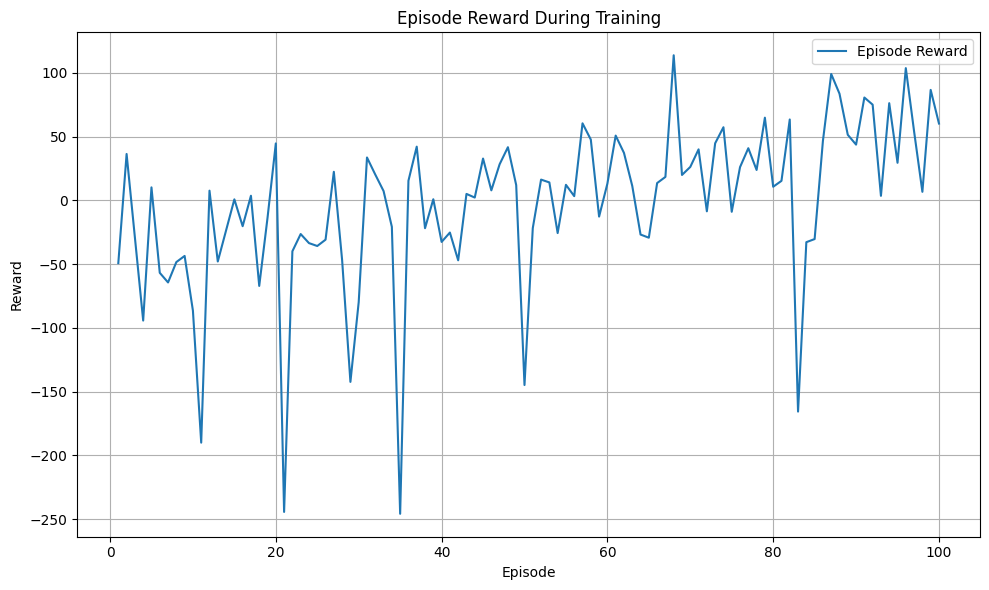

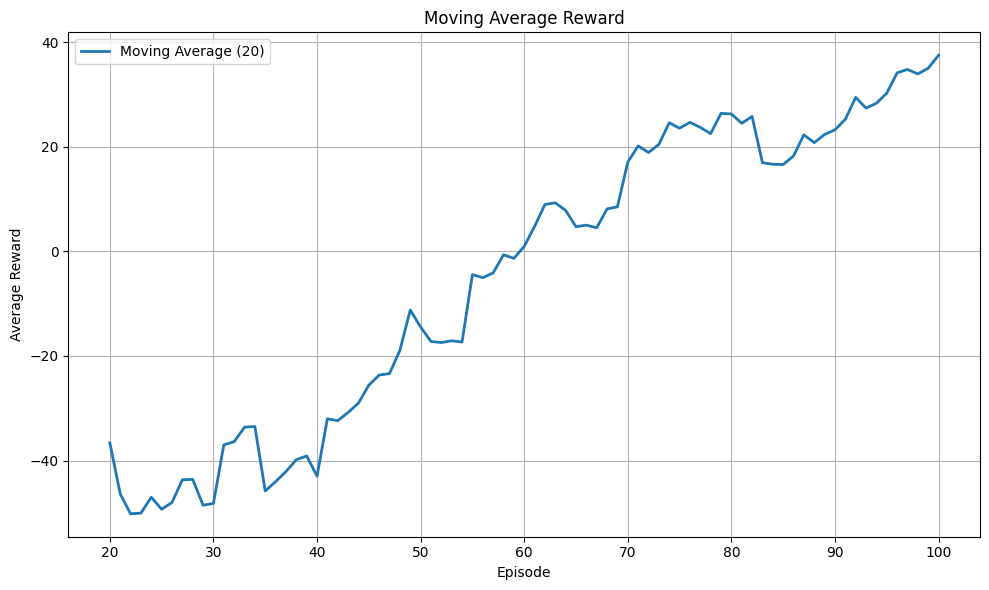

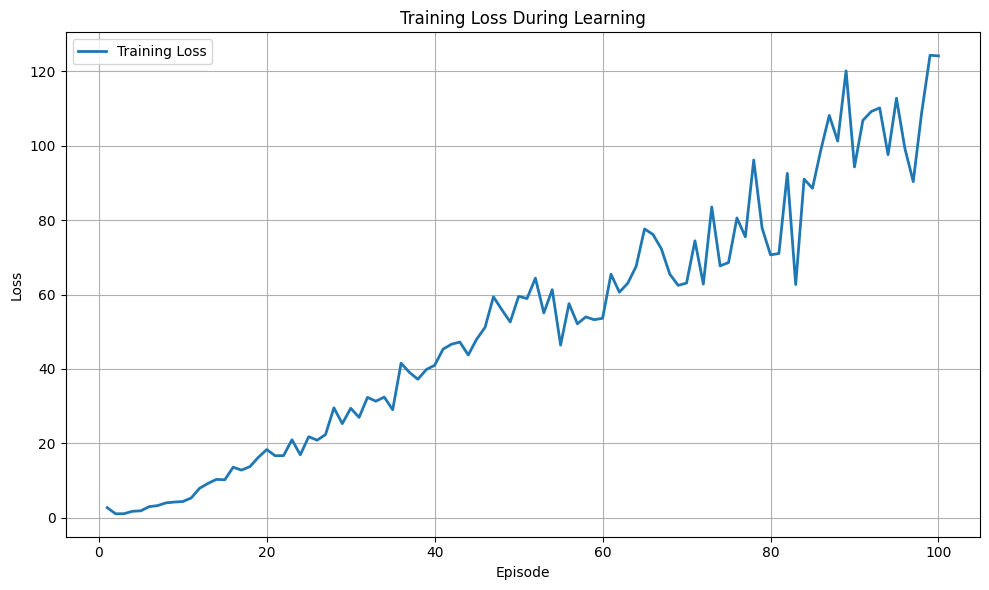

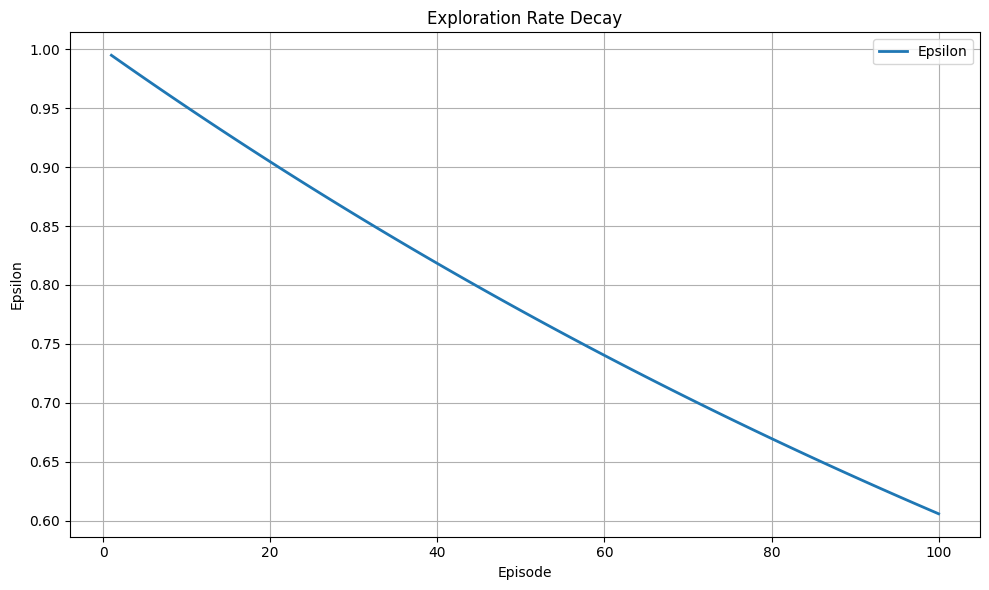

Training Statistics
Episodes        : 100
Best Reward     : 113.762
Worst Reward    : -245.842
Average Reward  : -2.975
Final Loss      : 124.1893
Final Epsilon   : 0.6058

All Figures Saved Successfully
Folder : Results


In [14]:
"""
============================================================
plots.py
============================================================

Visualization Utilities

Generate publication-quality figures for

1. Episode Reward
2. Moving Average Reward
3. Training Loss
4. Epsilon Decay

Author:
    Sara, Soha, Heba
============================================================
"""

import os
import numpy as np
import matplotlib.pyplot as plt


class TrainingPlots:

    """
    Plot training statistics.
    """

    def __init__(

            self,

            reward_history,

            loss_history,

            epsilon_history,

            save_dir="Results"

    ):

        self.reward_history = reward_history

        self.loss_history = loss_history

        self.epsilon_history = epsilon_history

        self.save_dir = save_dir

        os.makedirs(

            save_dir,

            exist_ok=True

        )

        print("=" * 60)
        print("Training Plotter Initialized")
        print("=" * 60)
        print(f"Reward Samples  : {len(reward_history)}")
        print(f"Loss Samples    : {len(loss_history)}")
        print(f"Epsilon Samples : {len(epsilon_history)}")
        print(f"Save Folder     : {save_dir}")
        print("=" * 60)
    # ==========================================================
    # Reward Curve
    # ==========================================================

    def plot_rewards(self, window=10):

        rewards = np.asarray(

            self.reward_history,

            dtype=np.float32

        )

        episodes = np.arange(

            1,

            len(rewards) + 1

        )

        plt.figure(

            figsize=(10, 6)

        )

        plt.plot(

            episodes,

            rewards,

            linewidth=1.5,

            label="Episode Reward"

        )

        plt.xlabel("Episode")

        plt.ylabel("Reward")

        plt.title("Episode Reward During Training")

        plt.grid(True)

        plt.legend()

        plt.tight_layout()

        plt.savefig(

            os.path.join(

                self.save_dir,

                "reward_curve.png"

            ),

            dpi=300

        )

        plt.show()

        plt.close()

    # ==========================================================
    # Moving Average Reward
    # ==========================================================

    def plot_moving_average(

            self,

            window=20

    ):

        rewards = np.asarray(

            self.reward_history,

            dtype=np.float32

        )

        if len(rewards) < window:

            print("Not enough episodes.")

            return

        moving_avg = np.convolve(

            rewards,

            np.ones(window) / window,

            mode="valid"

        )

        episodes = np.arange(

            window,

            len(rewards) + 1

        )

        plt.figure(

            figsize=(10, 6)

        )

        plt.plot(

            episodes,

            moving_avg,

            linewidth=2,

            label=f"Moving Average ({window})"

        )

        plt.xlabel("Episode")

        plt.ylabel("Average Reward")

        plt.title("Moving Average Reward")

        plt.grid(True)

        plt.legend()

        plt.tight_layout()

        plt.savefig(

            os.path.join(

                self.save_dir,

                "moving_average_reward.png"

            ),

            dpi=300

        )

        plt.show()

        plt.close()
    # ==========================================================
    # Loss Curve
    # ==========================================================

    def plot_loss(self):

        losses = np.asarray(

            self.loss_history,

            dtype=np.float32

        )

        episodes = np.arange(

            1,

            len(losses) + 1

        )

        plt.figure(

            figsize=(10, 6)

        )

        plt.plot(

            episodes,

            losses,

            linewidth=2,

            label="Training Loss"

        )

        plt.xlabel("Episode")

        plt.ylabel("Loss")

        plt.title("Training Loss During Learning")

        plt.grid(True)

        plt.legend()

        plt.tight_layout()

        plt.savefig(

            os.path.join(

                self.save_dir,

                "loss_curve.png"

            ),

            dpi=300

        )

        plt.show()

        plt.close()

    # ==========================================================
    # Epsilon Decay
    # ==========================================================

    def plot_epsilon(self):

        epsilon = np.asarray(

            self.epsilon_history,

            dtype=np.float32

        )

        episodes = np.arange(

            1,

            len(epsilon) + 1

        )

        plt.figure(

            figsize=(10, 6)

        )

        plt.plot(

            episodes,

            epsilon,

            linewidth=2,

            label="Epsilon"

        )

        plt.xlabel("Episode")

        plt.ylabel("Epsilon")

        plt.title("Exploration Rate Decay")

        plt.grid(True)

        plt.legend()

        plt.tight_layout()

        plt.savefig(

            os.path.join(

                self.save_dir,

                "epsilon_decay.png"

            ),

            dpi=300

        )

        plt.show()

        plt.close()

    # ==========================================================
    # Combined Statistics
    # ==========================================================

    def print_summary(self):

        print("=" * 60)
        print("Training Statistics")
        print("=" * 60)

        print(f"Episodes        : {len(self.reward_history)}")

        print(f"Best Reward     : {np.max(self.reward_history):.3f}")

        print(f"Worst Reward    : {np.min(self.reward_history):.3f}")

        print(f"Average Reward  : {np.mean(self.reward_history):.3f}")

        print(f"Final Loss      : {self.loss_history[-1]:.4f}")

        print(f"Final Epsilon   : {self.epsilon_history[-1]:.4f}")

        print("=" * 60)
    # ==========================================================
    # Plot Everything
    # ==========================================================

    def plot_all(self):

        print()

        print("=" * 60)
        print("Generating Training Figures...")
        print("=" * 60)

        self.plot_rewards()

        self.plot_moving_average()

        self.plot_loss()

        self.plot_epsilon()

        self.print_summary()

        print()

        print("=" * 60)
        print("All Figures Saved Successfully")
        print(f"Folder : {self.save_dir}")
        print("=" * 60)


# ============================================================
# Main
# ============================================================
if __name__ == "__main__":

    print("=" * 60)
    print("Loading Training History")
    print("=" * 60)

    with open("training_history.pkl", "rb") as f:

        history = pickle.load(f)

    plotter = TrainingPlots(

        reward_history=history["episode_rewards"],

        loss_history=history["episode_losses"],

        epsilon_history=history["epsilon_history"],

        save_dir="Results"

    )

    plotter.plot_all()

This module evaluates a trained DQN agent.
Example usage:

Model loaded from: best_dqn_agent.pth
DQN Evaluation Initialized
Episodes : 20
Model    : best_dqn_agent.pth

EVALUATION STARTED
Episode   1/20  Reward =  118.845
Episode   2/20  Reward =  161.964
Episode   3/20  Reward =  165.788
Episode   4/20  Reward =  201.485
Episode   5/20  Reward =  247.795
Episode   6/20  Reward =  181.082
Episode   7/20  Reward =  193.816
Episode   8/20  Reward =  175.996
Episode   9/20  Reward =  208.758
Episode  10/20  Reward =  133.829
Episode  11/20  Reward =  159.115
Episode  12/20  Reward =  160.857
Episode  13/20  Reward =  210.819
Episode  14/20  Reward = -104.256
Episode  15/20  Reward =  209.000
Episode  16/20  Reward =  232.395
Episode  17/20  Reward =  159.370
Episode  18/20  Reward =  276.058
Episode  19/20  Reward =  174.257
Episode  20/20  Reward =  267.311

EVALUATION SUMMARY
Episodes             : 20
Average Reward       : 176.714
Best Reward          : 276.058
Worst Reward         : -

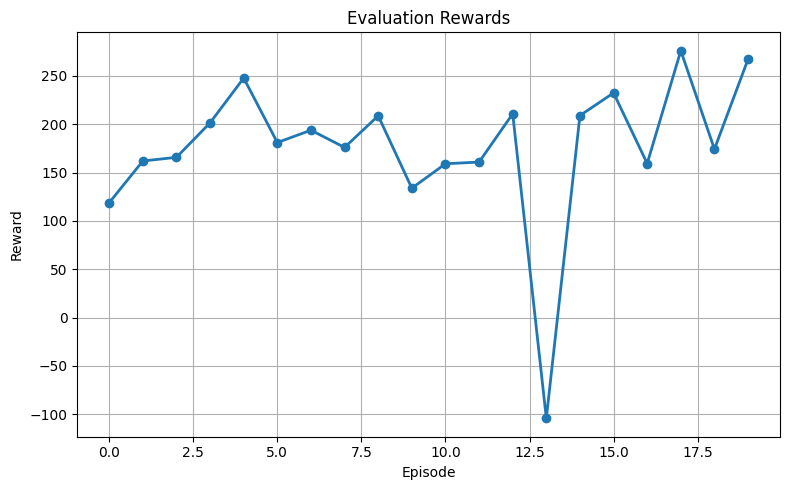

Results saved to: evaluation_results.txt


In [16]:
"""
============================================================
Evaluation.py
============================================================

Evaluate a trained DQN Pollution Agent
on the CityPulse Environment.

Author : Soha Moamen
"""

# ==========================================================
# Imports
# ==========================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

# ==========================================================
# Evaluation Class
# ==========================================================


class DQNEvaluator:

    """
    Evaluate trained DQN agent.
    """

    # ------------------------------------------------------

    def __init__(self,
                 env,
                 agent,
                 model_path="best_dqn_agent.pth",
                 episodes=20):

        self.env = env
        self.agent = agent

        self.model_path = model_path
        self.episodes = episodes

        # --------------------------------------------------
        # Load trained model
        # --------------------------------------------------

        if os.path.exists(model_path):

            self.agent.load(model_path)

        else:

            raise FileNotFoundError(model_path)

        # --------------------------------------------------

        self.rewards = []

        self.action_history = []

        self.air_scores = []

        self.traffic_scores = []

        print("=" * 60)
        print("DQN Evaluation Initialized")
        print("=" * 60)

        print("Episodes :", episodes)
        print("Model    :", model_path)

        print("=" * 60)
    # ======================================================
    # Evaluate One Episode
    # ======================================================

    def evaluate_episode(self):

        """
        Run one complete evaluation episode.

        Returns
        -------
        total_reward : float
        """

        state, _ = self.env.reset()

        done = False

        total_reward = 0.0

        step = 0

        # ----------------------------------------------
        # Disable Exploration
        # ----------------------------------------------

        old_epsilon = self.agent.epsilon
        self.agent.epsilon = 0.0

        while not done:

            # ------------------------------------------
            # Select Best Action
            # ------------------------------------------

            action = self.agent.select_action(state)

            # ------------------------------------------
            # Environment Step
            # ------------------------------------------

            next_state, reward, done, truncated, info = self.env.step(action)

            total_reward += reward

            # ------------------------------------------
            # Save Statistics
            # ------------------------------------------

            self.action_history.append(action)

            if "air_index" in info:

                self.air_scores.append(info["air_index"])

            if "traffic_index" in info:

                self.traffic_scores.append(info["traffic_index"])

            state = next_state

            step += 1

            if truncated:

                break

        # ----------------------------------------------
        # Restore Epsilon
        # ----------------------------------------------

        self.agent.epsilon = old_epsilon

        return total_reward
    # ======================================================
    # Evaluate Agent
    # ======================================================

    def evaluate(self):

        """
        Evaluate the trained agent over multiple episodes.
        """

        print()

        print("=" * 70)
        print("EVALUATION STARTED")
        print("=" * 70)

        self.rewards.clear()
        self.action_history.clear()
        self.air_scores.clear()
        self.traffic_scores.clear()

        # --------------------------------------------------
        # Run Episodes
        # --------------------------------------------------

        for episode in range(self.episodes):

            reward = self.evaluate_episode()

            self.rewards.append(reward)

            print(
                f"Episode {episode + 1:3d}/{self.episodes:<3d} "
                f"Reward = {reward:8.3f}"
            )

        # --------------------------------------------------
        # Statistics
        # --------------------------------------------------

        average_reward = np.mean(self.rewards)

        best_reward = np.max(self.rewards)

        worst_reward = np.min(self.rewards)

        std_reward = np.std(self.rewards)

        action_counter = Counter(

            self.action_history

        )

        self.results = {

            "episodes": self.episodes,

            "average_reward": average_reward,

            "best_reward": best_reward,

            "worst_reward": worst_reward,

            "reward_std": std_reward,

            "average_air_index":

                np.mean(self.air_scores)

                if len(self.air_scores) > 0

                else 0.0,

            "average_traffic_index":

                np.mean(self.traffic_scores)

                if len(self.traffic_scores) > 0

                else 0.0,

            "action_distribution":

                dict(action_counter)

        }

        # --------------------------------------------------

        print()

        print("=" * 70)
        print("EVALUATION SUMMARY")
        print("=" * 70)

        print(f"Episodes             : {self.results['episodes']}")

        print(f"Average Reward       : {self.results['average_reward']:.3f}")

        print(f"Best Reward          : {self.results['best_reward']:.3f}")

        print(f"Worst Reward         : {self.results['worst_reward']:.3f}")

        print(f"Reward Std           : {self.results['reward_std']:.3f}")

        print(f"Average Air Index    : {self.results['average_air_index']:.3f}")

        print(f"Average Traffic Index: {self.results['average_traffic_index']:.3f}")

        print()

        print("Action Distribution")

        for action, count in action_counter.items():

            print(

                f"Action {action} : {count}"

            )

        print("=" * 70)

        return self.results
    # ======================================================
    # Plot Reward Distribution
    # ======================================================

    def plot_rewards(self):

        plt.figure(figsize=(8,5))

        plt.plot(

            self.rewards,

            marker="o",

            linewidth=2

        )

        plt.xlabel("Episode")

        plt.ylabel("Reward")

        plt.title("Evaluation Rewards")

        plt.grid(True)

        plt.tight_layout()

        plt.savefig(

            "evaluation_rewards.png",

            dpi=300

        )

        plt.show()

        plt.close()

    # ======================================================
    # Save Results
    # ======================================================

    def save_results(

            self,

            filename="evaluation_results.txt"

    ):

        with open(filename, "w") as f:

            f.write("=" * 60 + "\n")

            f.write("DQN Evaluation Results\n")

            f.write("=" * 60 + "\n\n")

            for key, value in self.results.items():

                f.write(f"{key} : {value}\n")

        print(f"Results saved to: {filename}")

# ==========================================================
# Main
# ==========================================================

if __name__ == "__main__":

    print("=" * 60)

    print("This module evaluates a trained DQN agent.")

    print("Example usage:")

    print()

    #print("""
    evaluator = DQNEvaluator(env,agent,model_path="best_dqn_agent.pth",episodes=20)

    results = evaluator.evaluate()

    evaluator.plot_rewards()

    evaluator.save_results()

#""")

    print("=" * 60)

In [36]:
"""
============================================================
PollutionDecision.py
============================================================

Decision Generator for the trained Pollution Agent.

This module loads the trained DQN model and generates
a decision proposal for the Meta Controller.

Author : Soha Moamen
"""

# ==========================================================
# Imports
# ==========================================================

import numpy as np
import torch

# ==========================================================
# Pollution Decision Class
# ==========================================================

class PollutionDecision:

    """
    Generate decision proposals using the trained
    Pollution DQN Agent.
    """

    # ------------------------------------------------------

    def __init__(self,
                 agent,
                 model_path="best_dqn_agent.pth"):

        self.agent = agent

        self.model_path = model_path

        # --------------------------------------------------
        # Load trained model
        # --------------------------------------------------

        self.agent.load(model_path)

        # Evaluation Mode

        self.agent.online_network.eval()

        # Action Names

        self.action_names = {

            0: "No Action",

            1: "Eco Routing",

            2: "Emission Restriction"

        }

        print("=" * 60)
        print("Pollution Decision Generator Initialized")
        print("=" * 60)
        print(f"Model : {model_path}")
        print("=" * 60)
    # ======================================================
    # Generate Decision Proposal
    # ======================================================
    def generate_proposal(
        self,
        state,
        snapshot_id=None,
        timestamp=None):
    #def generate_proposal(self, state):

        """
        Generate a decision proposal for one city snapshot.

        Parameters
        ----------
        state : ndarray
            Current city state.

        Returns
        -------
        proposal : dict
        """

        # --------------------------------------------------
        # Disable exploration
        # --------------------------------------------------

        old_epsilon = self.agent.epsilon

        self.agent.epsilon = 0.0

        # --------------------------------------------------
        # Select Best Action
        # --------------------------------------------------

        action = self.agent.select_action(state)

        # --------------------------------------------------
        # Estimate Q-values
        # --------------------------------------------------

        state_scaled = self.agent.scaler.transform([state])

        state_tensor = torch.FloatTensor(

            state_scaled

        ).to(self.agent.device)

        with torch.no_grad():

            q_values = self.agent.online_network(

                state_tensor

            ).cpu().numpy()[0]

        # --------------------------------------------------
        # Confidence
        # --------------------------------------------------

        q_shift = q_values - np.max(q_values)

        probabilities = np.exp(q_shift)

        probabilities /= probabilities.sum()

        confidence = float(

            probabilities[action]

        )

        expected_reward = float(

            q_values[action]

        )

        # --------------------------------------------------
        # Priority
        # --------------------------------------------------

        priority = float(

            confidence * abs(expected_reward)

        )

        # --------------------------------------------------
        # Restore epsilon
        # --------------------------------------------------

        self.agent.epsilon = old_epsilon

        # --------------------------------------------------
        # Decision Proposal
        # --------------------------------------------------
        """
        proposal = {

            "agent": "Pollution",

            "recommended_action": action,

            "action_name": self.action_names[action],

            "expected_reward": expected_reward,

            "confidence": confidence,

            "priority": priority

        }
        """
        proposal = {

            "agent": "Pollution",

            "snapshot": snapshot_id,

            "timestamp": str(timestamp),

            "recommended_action": action,

            "action_name": self.action_names[action],

            "expected_reward": expected_reward,

            "confidence": confidence,

            "priority": priority

        }

        return proposal
    # ======================================================
    # Print Decision Proposal
    # ======================================================

    def print_proposal(self, proposal):

        """
        Print the generated proposal.
        """

        print()

        print("=" * 60)
        print("POLLUTION AGENT DECISION")
        print("=" * 60)

        print(f"Agent            : {proposal['agent']}")

        print(f"Action           : {proposal['action_name']}")

        print(f"Action ID        : {proposal['recommended_action']}")

        print(f"Expected Reward  : {proposal['expected_reward']:.4f}")

        print(f"Confidence       : {proposal['confidence']:.4f}")

        print(f"Priority         : {proposal['priority']:.4f}")

        print("=" * 60)


    # ======================================================
    # Proposal as Dictionary
    # ======================================================
    def get_proposal(
        self,
        state,
        snapshot_id=None,
        timestamp=None
    ):

        return self.generate_proposal(
            state,
            snapshot_id=snapshot_id,
            timestamp=timestamp
        )
        """
    def get_proposal(self, state):


        Generate and return proposal.



        proposal = self.generate_proposal(state)

        return proposal

"""
    # ======================================================
    # Proposal as JSON
    # ======================================================

    def to_json(self, proposal):

        """
        Convert proposal into JSON string.
        """

        import json

        return json.dumps(

            proposal,

            indent=4

        )


    # ======================================================
    # String Representation
    # ======================================================

    def __str__(self):

        return (

            f"PollutionDecision(model='{self.model_path}')"

        )
# ==========================================================
# Main
# ==========================================================
"""
if __name__ == "__main__":

    print("=" * 70)
    print("POLLUTION DECISION TEST")
    print("=" * 70)

    # ------------------------------------------------------
    # Data Manager
    # ------------------------------------------------------

    manager = CityPulseDataManager()

    # ------------------------------------------------------
    # Environment
    # ------------------------------------------------------

    env = CityPulseEnvironment(

        manager=manager,

        episode_length=1,

        random_start=False

    )

    # ------------------------------------------------------
    # DQN Agent
    # ------------------------------------------------------

    agent = DQNAgent(

        state_size=len(manager.feature_names),

        action_size=3,

        manager=manager

    )

    # ------------------------------------------------------
    # Decision Generator
    # ------------------------------------------------------

    decision = PollutionDecision(

        agent,

        model_path="best_dqn_agent.pth"

    )

    # ------------------------------------------------------
    # Get Current State
    # ------------------------------------------------------

    state, _ = env.reset()

    # ------------------------------------------------------
    # Generate Proposal
    # ------------------------------------------------------

    proposal = decision.get_proposal(state)

    # ------------------------------------------------------
    # Print Proposal
    # ------------------------------------------------------

    decision.print_proposal(proposal)

    # ------------------------------------------------------
    # JSON
    # ------------------------------------------------------

    print()

    print("=" * 70)

    print("JSON FORMAT")

    print("=" * 70)

    print(

        decision.to_json(proposal)

    )

    # ------------------------------------------------------

    env.close()

    print()

    print("=" * 70)

    print("POLLUTION DECISION COMPLETED")

    print("=" * 70)
    """

'\nif __name__ == "__main__":\n\n    print("=" * 70)\n    print("POLLUTION DECISION TEST")\n    print("=" * 70)\n\n    # ------------------------------------------------------\n    # Data Manager\n    # ------------------------------------------------------\n\n    manager = CityPulseDataManager()\n\n    # ------------------------------------------------------\n    # Environment\n    # ------------------------------------------------------\n\n    env = CityPulseEnvironment(\n\n        manager=manager,\n\n        episode_length=1,\n\n        random_start=False\n\n    )\n\n    # ------------------------------------------------------\n    # DQN Agent\n    # ------------------------------------------------------\n\n    agent = DQNAgent(\n\n        state_size=len(manager.feature_names),\n\n        action_size=3,\n\n        manager=manager\n\n    )\n\n    # ------------------------------------------------------\n    # Decision Generator\n    # -------------------------------------------------

In [20]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    print(root)

/content/drive/MyDrive
/content/drive/MyDrive/كتب الكتاب
/content/drive/MyDrive/تربية شعبة الحاسب الالي
/content/drive/MyDrive/تربية شعبة الحاسب الالي/قواعد البيانات المتقدمة
/content/drive/MyDrive/تربية شعبة الحاسب الالي/قواعد البيانات المتقدمة/المحتوي النظري
/content/drive/MyDrive/تربية شعبة الحاسب الالي/قواعد البيانات المتقدمة/المحتوي العملي
/content/drive/MyDrive/تربية شعبة الحاسب الالي/بنية الحاسب
/content/drive/MyDrive/تربية شعبة الحاسب الالي/بنية الحاسب/المحتوي النظري
/content/drive/MyDrive/تربية شعبة الحاسب الالي/بنية الحاسب/المحتوي العملي
/content/drive/MyDrive/تربية شعبة الحاسب الالي/مقدمة في قواعد البيانات
/content/drive/MyDrive/تربية شعبة الحاسب الالي/مقدمة في قواعد البيانات/المحاضرات 
/content/drive/MyDrive/تربية شعبة الحاسب الالي/File
/content/drive/MyDrive/APM 2022
/content/drive/MyDrive/APM 2022/Apm Projects 
/content/drive/MyDrive/APM 2022/دواعي التخرج
/content/drive/MyDrive/APM 2022/Slides
/content/drive/MyDrive/APM 2022/Templates
/content/drive/MyDrive/system analysi

In [38]:
"""
============================================================
test_pollution_decision.py
============================================================

Test the Pollution Decision Generator

Author : Soha Moamen
"""

# ==========================================================
# Imports
# ==========================================================

# from CityPulseDataManager import CityPulseDataManager
# from CityPulseEnvironment import CityPulseEnvironment
# from DQNAgent import DQNAgent
# from PollutionDecision import PollutionDecision

# ==========================================================
# Dataset Path
# ==========================================================

BASE_PATH = r"/content/drive/MyDrive/AI Agent/final dataset/"

# ==========================================================
# Data Manager
# ==========================================================

manager = CityPulseDataManager(
    base_path=BASE_PATH
)

# Load previously generated snapshot
manager.load_snapshot()

manager.build_temporal_index()

manager.build_cache()

# ==========================================================
# Environment
# ==========================================================

env = CityPulseEnvironment(
    manager=manager,
    episode_length=1,
    random_start=False
)

# ==========================================================
# DQN Agent
# ==========================================================

agent = DQNAgent(
    state_size=len(manager.feature_names),
    action_size=3,
    manager=manager
)

# ==========================================================
# Pollution Decision Generator
# ==========================================================

decision = PollutionDecision(
    agent=agent,
    model_path="best_dqn_agent.pth"
)

# ==========================================================
# Initial Snapshot
# ==========================================================

initial_step = 0

state = manager.get_state(initial_step)

timestamp = manager.get_timestamp(initial_step)

print()

print("=" * 70)
print("INITIAL CITY SNAPSHOT")
print("=" * 70)

print("Timestamp :", timestamp)
print("Step      :", initial_step)
print("State Shape :", state.shape)

# ==========================================================
# Decision Proposal
# ==========================================================

proposal = decision.generate_proposal(
    state=state,
    snapshot_id=initial_step,
    timestamp=timestamp
)

# ==========================================================
# Print Proposal
# ==========================================================

decision.print_proposal(proposal)

# ==========================================================
# JSON
# ==========================================================

print()

print("=" * 70)
print("JSON FORMAT")
print("=" * 70)

print(
    decision.to_json(proposal)
)

# ==========================================================
# Multiple Snapshot Test
# ==========================================================

print()

print("=" * 70)
print("MULTIPLE SNAPSHOT TEST")
print("=" * 70)

test_steps = [0, 500, 1000, 2000, 3000]

for step in test_steps:

    state = manager.get_state(step)

    timestamp = manager.get_timestamp(step)

    proposal = decision.generate_proposal(
        state=state,
        snapshot_id=step,
        timestamp=timestamp
    )

    print(
        f"Step={step:4d} | "
        f"{timestamp} | "
        f"{proposal['action_name']:25s} | "
        f"Reward={proposal['expected_reward']:.3f} | "
        f"Confidence={proposal['confidence']:.3f}"
    )

# ==========================================================
# Close Environment
# ==========================================================

env.close()

print()

print("=" * 70)
print("ALL TESTS PASSED SUCCESSFULLY")
print("=" * 70)

Reward Engine Initialized
Monitored Features
no2_mean          Mean=111.701   Std=7.842
pm_mean           Mean=112.090   Std=8.464
co_mean           Mean=112.414   Std=7.788
vehicle_count     Mean=5060.065   Std=4454.012
avg_speed         Mean=47.161   Std=4.493
CityPulse Reinforcement Learning Environment
Snapshots      : 4392
Features       : 32
Actions        : 3
Episode Length : 1
Random Start   : False
Deep Q-Network Initialized
Input Features : 32
Hidden Layer 1 : 128
Hidden Layer 2 : 64
Actions         : 3
Deep Q-Network Initialized
Input Features : 32
Hidden Layer 1 : 128
Hidden Layer 2 : 64
Actions         : 3
Replay Buffer Initialized
Capacity : 100,000
Deep Q-Learning Agent Initialized
Device          : cpu
State Size      : 32
Action Size     : 3
Replay Capacity : 100,000
Batch Size      : 64
Gamma           : 0.99
Epsilon         : 1.0
Learning Rate   : 0.001
Model loaded from: best_dqn_agent.pth
Pollution Decision Generator Initialized
Model : best_dqn_agent.pth

INITIAL 